# Maldroid Classifier based on API Sequences

## Estructura del notebook

Este notebook integra los hallazgos del equipo en **fases incrementales**, cada una construyendo sobre la anterior:

| Fase | Enfoque | Idea principal |
|---|---|---|
| **Base** | TF-IDF + MLP | Baseline *bag-of-words* sobre frecuencias de API |
| **Fase 1** | BiLSTM | Modelar el *orden* de las llamadas con una red recurrente |
| **Fase 2** | Focal Loss | Atacar el desbalance de clases (Adware minoritaria) |
| **Fase 3** | Dual-View Fusion | Fusionar la vista estadística y la secuencial (4 estrategias + ensemble) |

Ejecutar con **Runtime -> Run all**. Las Fases 1-3 requieren GPU (T4) para tiempos razonables.

## Explore Data

In [1]:
# === Setup para Google Colab / local ===
import sys, subprocess
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Detectado Google Colab. Instalando dependencias...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "pytorch_lightning==2.6.1", "transformers"], check=False)
    from google.colab import drive
    try:
        drive.mount("/content/drive", force_remount=False)
    except Exception as e:
        print("No se pudo montar Drive (puede que ya esté montado):", e)

# detectar hardware
import torch
DEVICE_KIND = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"PyTorch {torch.__version__}  |  Dispositivo: {DEVICE_KIND}")
if DEVICE_KIND == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Detectado Google Colab. Instalando dependencias...
Mounted at /content/drive
PyTorch 2.10.0+cu128  |  Dispositivo: cuda
  GPU: Tesla T4
  VRAM: 15.6 GB


In [2]:
# libraries
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score

import pytorch_lightning as L
import torch.nn.functional as F
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from torch.nn.utils.rnn import pad_sequence  # FASE 1: padding de secuencias


import warnings
warnings.filterwarnings('ignore')

In [3]:
# === Cargar dataset (Colab + local) ===
import os, glob

# Donde buscar el dataset (en orden). Para Colab, sube tu carpeta Sequence a Drive
# o usa `files.upload()`. El primer path que exista se usa.
_candidates = [
    # local (ejecutando desde la raíz del repo)
    "../datasets/Sequence",
    # local (worktree)
    "../../../datasets/Sequence",
    # Colab: subido a /content
    "/content/datasets/Sequence",
    "/content/Sequence",
    # Colab: en Drive
    "/content/drive/MyDrive/MLT_project/datasets/Sequence",
    "/content/drive/MyDrive/datasets/Sequence",
    "/content/drive/MyDrive/Sequence",
]
DATA_DIR = next((d for d in _candidates if os.path.isdir(d)), None)

if DATA_DIR is None:
    raise FileNotFoundError(
        "No se encontró la carpeta Sequence. Súbela a Drive o /content/.\n"
        "Buscado en:\n  " + "\n  ".join(_candidates)
    )

print(f"Cargando dataset desde: {DATA_DIR}")
with open(os.path.join(DATA_DIR, "train-sequence.json"), "r") as f:
    train_data = json.load(f)
with open(os.path.join(DATA_DIR, "test-sequence.json"), "r") as f:
    test_data = json.load(f)

df_train = pd.DataFrame(train_data)
df_test = pd.DataFrame(test_data)
print(f"Train: {len(df_train)} | Test: {len(df_test)}")


Cargando dataset desde: /content/drive/MyDrive/Sequence
Train: 11683 | Test: 5008


In [4]:
# explore data
df_train.head()

,GMLnames,Label,Class
0,2108820187ab171c48e01e13df69a0790491995d72dcc5...,reset setLength length length stopTransaction ...,sms
1,c612a7e7397d081d9f0dae615b1df8d88a08c0713879c2...,handleMessage setText run sendMessage obtainMe...,sms
2,360e3286184ddd26fd77112ac52006ede82a883b94b5db...,getNumber toString onCreate setContentView sta...,sms
3,ab4a071d06ff8fc999133858b30039c6ae1751de54b5bd...,onReceive onStart findViewById onCreate onCrea...,adware
4,7196812142d7b61cb95cf3ad8a77928f,b toString append a close a hasNext iterator v...,riskware


In [5]:
df_train.iloc[1]['Label']

'handleMessage setText run sendMessage obtainMessage init findViewById run onClick onClick onStart getSystemService currentTimeMillis onReceive startService onCreate init startActivity getSystemService parse length getPackageName setContentView toString a toString append init append a startActivity onCreate init findViewById setContentView onCreate setContentView onOptionsItemSelected addFlags onCreateOptionsMenu add getString onCreate setProgress startActivity setContentView setOnClickListener findViewById onCreate init init getString a substring printStackTrace parseInt equals b init close a parse'

In [6]:
df_test.head()

,GMLnames,Label,Class
0,9bdbc17f7ce3767f03fc10b901b3a823,onCreate startOauthAuthorization startActivity...,riskware
1,46fcfd232e17e649acd2997142cef963b9e7fa955e1d35...,run run run d c onCreate licButtonClick1 endBu...,sms
2,37a060eb3cce65ddbf4eac4cff025baf,convertToString bindView setViewImage getStrin...,riskware
3,42bfb5a49f794de3b746c992eceb67cf35e8e5ec60140f...,getPref3 onReceive onCreate setContentView ini...,sms
4,c8280b8acebcf7441317414c6a6acfb3,clinit printStackTrace next next dumpStack ins...,riskware


Count the number of different api calls on the label. This label is the written sequence of api calls, por exampoe, "onCreate startOauthAuthorization ..." indicates that there is a sequence of api calls that starts with onCreate, then startOauthAuthorization, and so on. We want to count how many different api calls are there in the dataset.

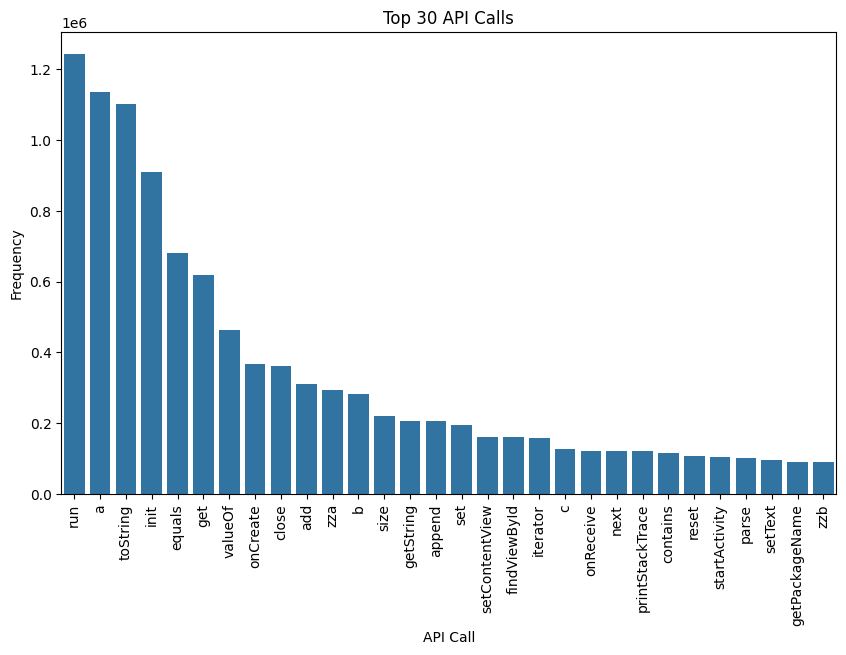

There are 209877 different API calls in the dataset.


In [7]:
# join all the labels in a single string
all_labels = " ".join(df_train['Label'].tolist())

# split the string into a list of api calls
api_calls = all_labels.split()

# count the number of different api calls and their frequency
api_calls_count = pd.Series(api_calls).value_counts()

# plot the top 30 api calls
plt.figure(figsize=(10,6))
sns.barplot(x=api_calls_count[:30].index, y=api_calls_count[:30].values)
plt.xticks(rotation=90)
plt.title("Top 30 API Calls")
plt.xlabel("API Call")
plt.ylabel("Frequency")
plt.show()

# print how many different api calls are there in the dataset
print(f"There are {len(api_calls_count)} different API calls in the dataset.")

Count the api calls most frequently used on each malware type (Class). This will give us an idea of which api calls are more relevant for each malware type, and we can use this information to select the most relevant features for our model.

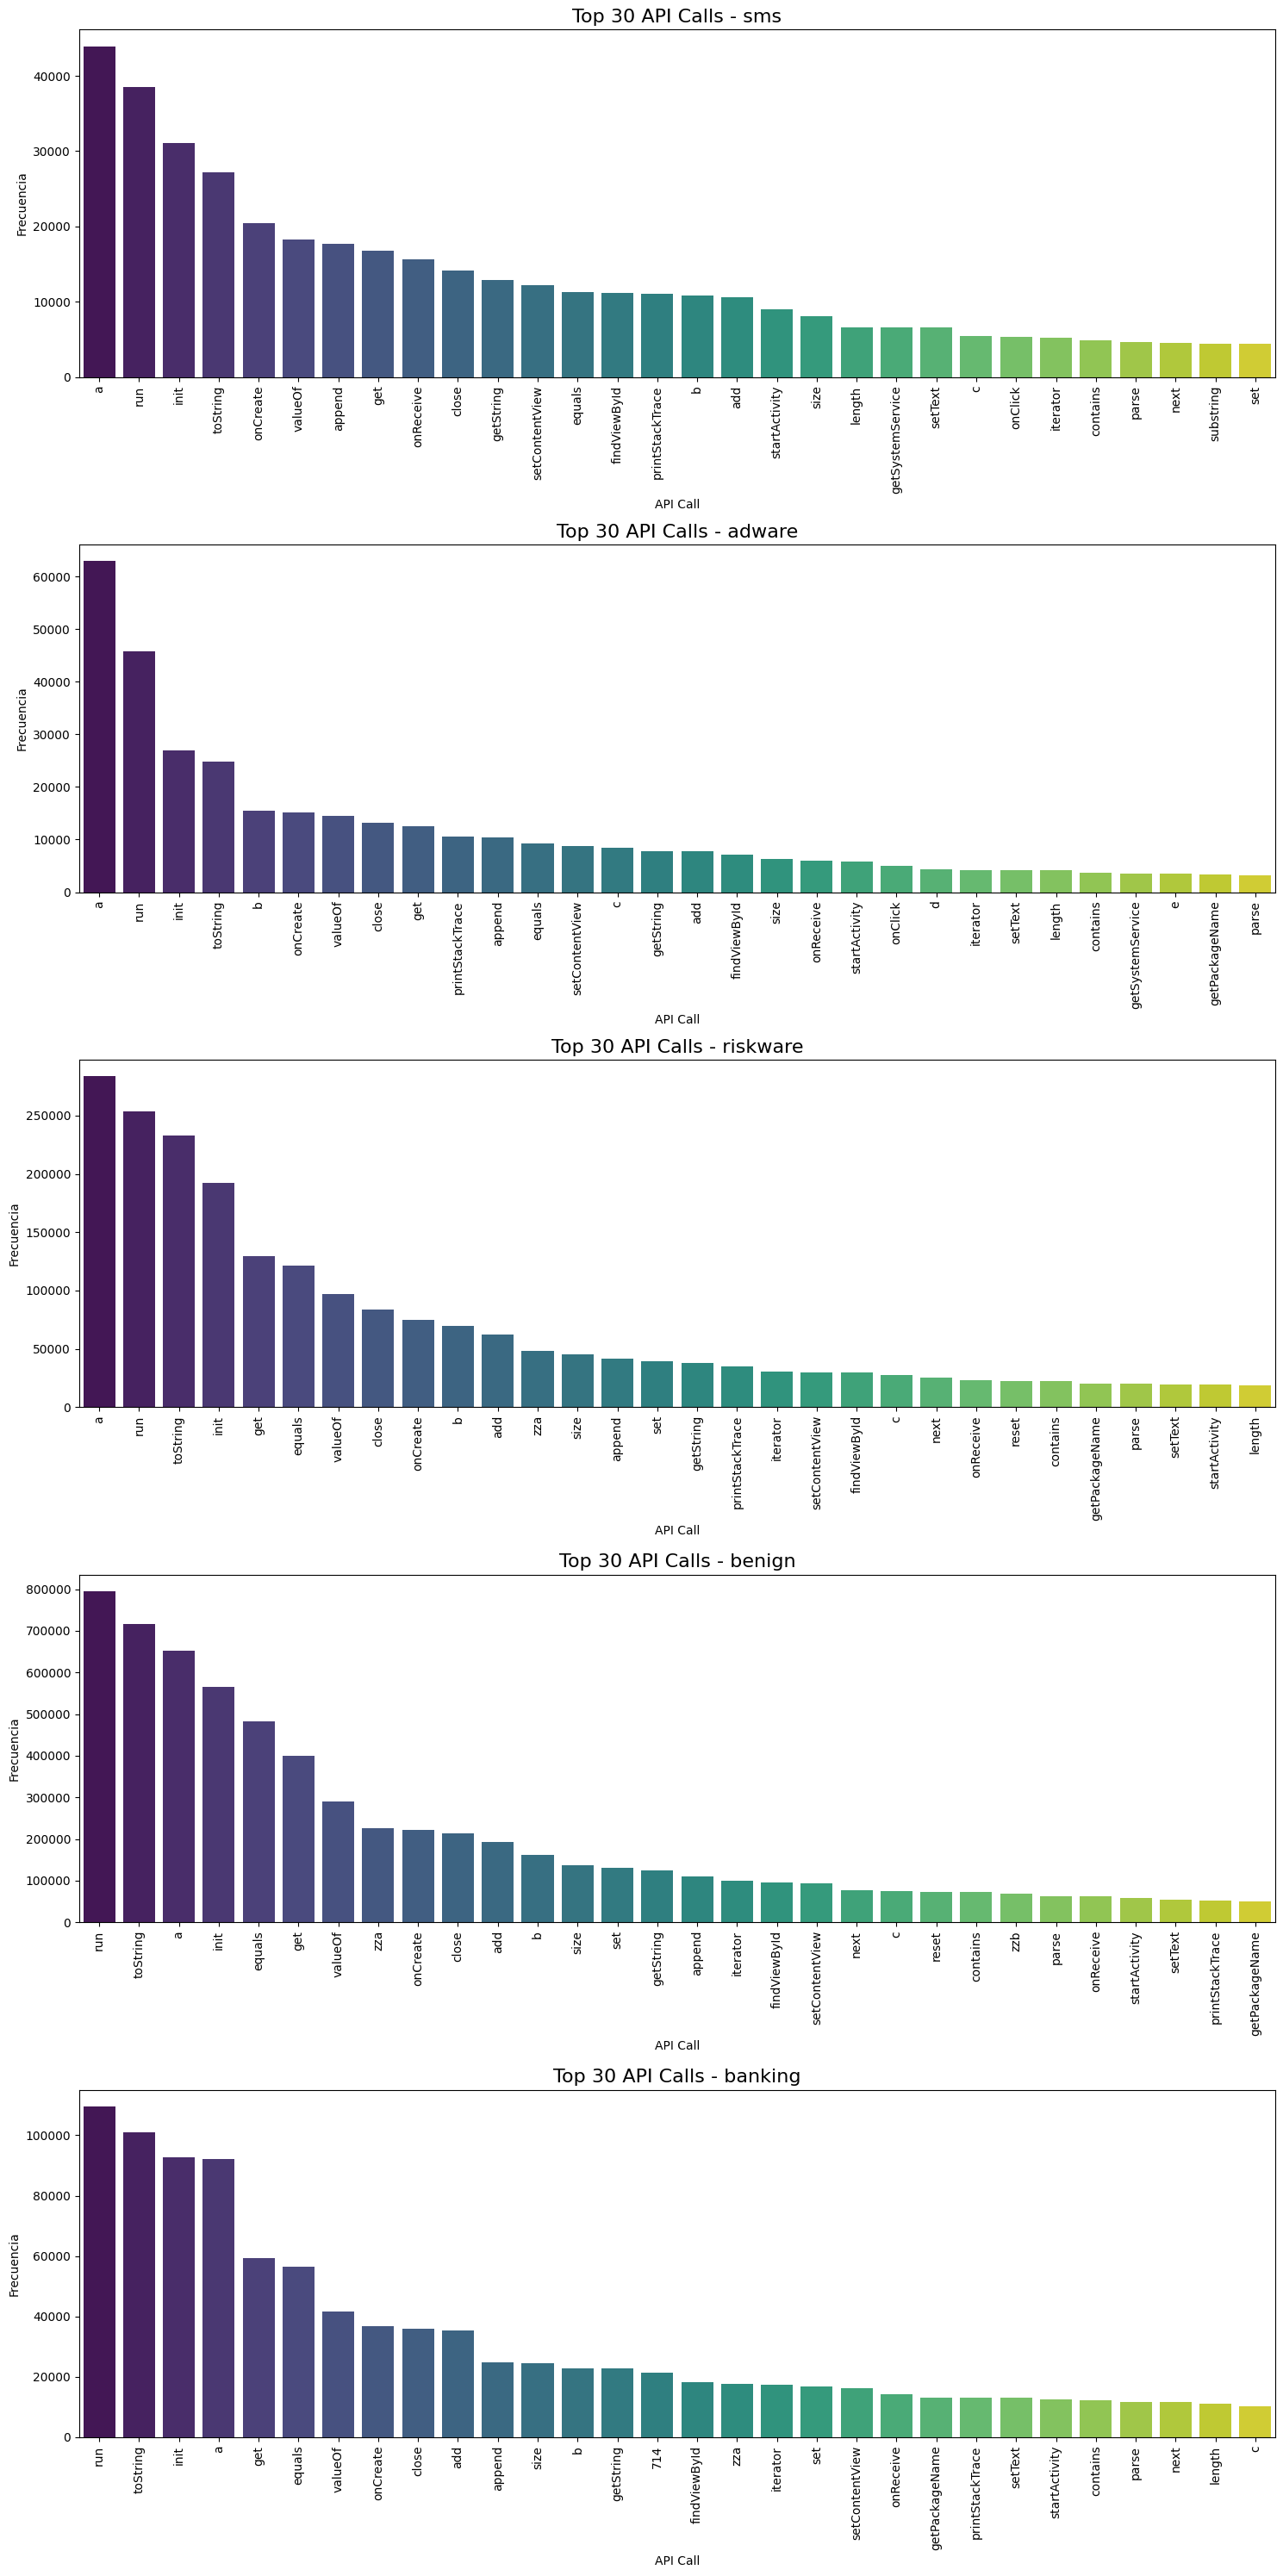

In [8]:
df_exploded = df_train.assign(Label=df_train['Label'].str.split()).explode('Label')

classes = df_train['Class'].unique()
n_classes = len(classes)

fig, axes = plt.subplots(nrows=n_classes, ncols=1, figsize=(15, 6 * n_classes))

if n_classes == 1:
    axes = [axes]

for i, malware_type in enumerate(classes):
    class_data = df_exploded[df_exploded['Class'] == malware_type]
    top_30_class = class_data['Label'].value_counts().nlargest(30)

    sns.barplot(
        x=top_30_class.index,
        y=top_30_class.values,
        ax=axes[i],
        palette="viridis"
    )

    axes[i].set_title(f'Top 30 API Calls - {malware_type}', fontsize=16)
    axes[i].set_xticklabels(top_30_class.index, rotation=90)
    axes[i].set_ylabel('Frecuencia')
    axes[i].set_xlabel('API Call')

plt.tight_layout()
plt.show()

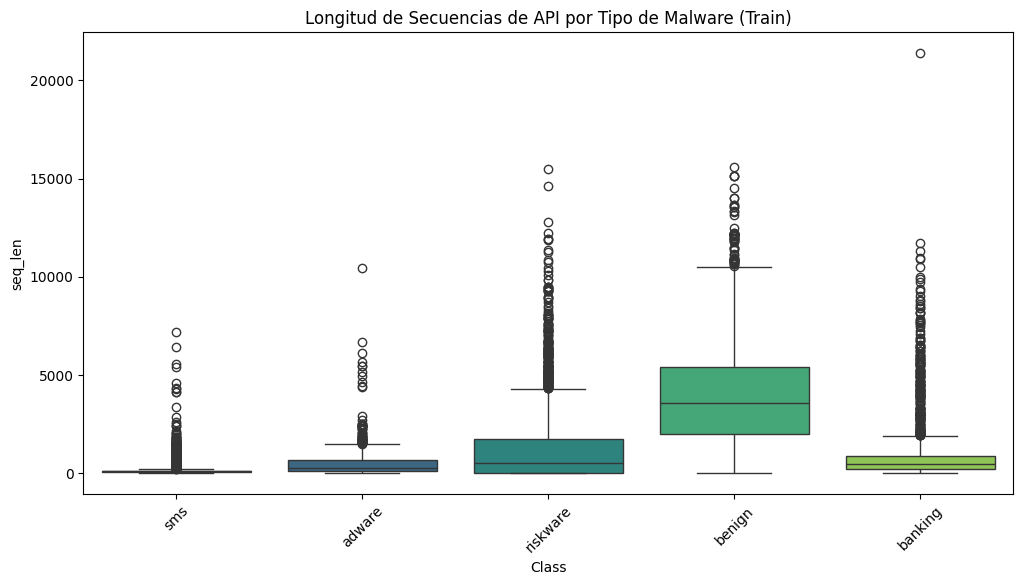

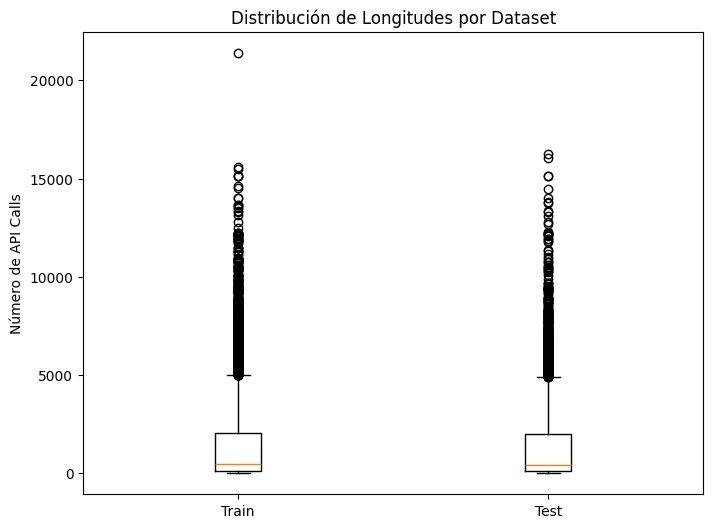

In [9]:
# distribucion de longitud de las secuencias (en todo el dataset)
# graficar boxplots por conjunto de datos (train y test)

df_train['seq_len'] = df_train['Label'].apply(lambda x: len(str(x).split()))
df_test['seq_len'] = df_test['Label'].apply(lambda x: len(str(x).split()))

# 1. Boxplot por Clase (Solo en Train para ver comportamiento del Malware)
plt.figure(figsize=(12, 6))
sns.boxplot(x='Class', y='seq_len', data=df_train, palette="viridis")
plt.title("Longitud de Secuencias de API por Tipo de Malware (Train)")
plt.xticks(rotation=45)
plt.show()

# 2. Comparación entre Conjuntos (para asegurar que la partición fue equitativa)
plt.figure(figsize=(8, 6))
data_to_plot = [df_train['seq_len'], df_test['seq_len']]
plt.boxplot(data_to_plot, labels=['Train', 'Test'])
plt.title("Distribución de Longitudes por Dataset")
plt.ylabel("Número de API Calls")
plt.show()

Ideas:
- Use CountVectorizer to tokenize the api calls as string and create a sparse matrix of token counts. It could make sense since the frecuency of api calls is relevant for the classification task. We can also use TfidfVectorizer.
- Train an embedding layer to learn a dense representation of the api calls.
- Use a RNN or LSTM model to capture the sequential nature of the api calls. This could be useful since the order of the api calls is relevant for the classification task.

## Data Preprocessing
1. Split the training set into training and validation.
2. Tokenize the api calls using CountVectorizer or TfidfVectorizer.
3. Train a model using the training data and evaluate it on the testing data.

In [10]:
# separar un 10% del conjunto de entrenamiento para validación
df_train_new, df_val = train_test_split(
    df_train,
    test_size=0.10,
    random_state=26,
    stratify=df_train['Class']
)

# tamaños
print(f"Train set: {len(df_train_new)} samples")
print(f"Validation set: {len(df_val)} samples")
print(f"Test set: {len(df_test)} samples")

# encoding de las etiquetas
le = LabelEncoder()
y_train_num = le.fit_transform(df_train_new['Class'])
y_val_num = le.transform(df_val['Class'])
y_test_num = le.transform(df_test['Class'])

# vectorizar con tfidf - cada secuencia de llamada se toma como un documento
# se limita el vocabulario a las 1000 llamadas mas frecuentes y se consideran n-gramas de 1 y 2
tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(df_train_new['Label']).toarray()
X_val_tfidf = tfidf.transform(df_val['Label']).toarray()
X_test_tfidf = tfidf.transform(df_test['Label']).toarray()

# convertir a tensores de PyTorch
X_train_t = torch.FloatTensor(X_train_tfidf)
y_train_t = torch.LongTensor(y_train_num)
X_val_t = torch.FloatTensor(X_val_tfidf)
y_val_t = torch.LongTensor(y_val_num)
X_test_t = torch.FloatTensor(X_test_tfidf)
y_test_t = torch.LongTensor(y_test_num)

# crear los dataloaders para entrenamiento, validación y test
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)

Train set: 10514 samples
Validation set: 1169 samples
Test set: 5008 samples


In [11]:
class MalwareMLP(L.LightningModule):
    def __init__(self, input_dim, num_classes, lr=0.0005):
        super().__init__()
        # guardar hiperparametros
        self.save_hyperparameters()

        # arquitecutra del modelo
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(32, num_classes)
        )

        # guardar learning rate
        self.lr = lr

        # diccionario para almacenar el promedio de métricas por época
        self.history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()

        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_acc", acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()

        self.log("val_loss", loss, on_epoch=True, prog_bar=True)
        self.log("val_acc", acc, on_epoch=True, prog_bar=True)
        return loss

    def on_validation_epoch_end(self):
        metrics = self.trainer.callback_metrics

        # Solo guardamos si las métricas existen (evita errores en la época 0)
        if "train_loss" in metrics and "val_loss" in metrics:
            self.history['train_loss'].append(metrics["train_loss"].item())
            self.history['train_acc'].append(metrics["train_acc"].item())
            self.history['val_loss'].append(metrics["val_loss"].item())
            self.history['val_acc'].append(metrics["val_acc"].item())

    def configure_optimizers(self):
        # Weight decay (L2) ayuda a que los pesos no crezcan demasiado
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr, weight_decay=1e-4)

        # Scheduler para reducir el LR cuando la pérdida de validación se estanque
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=5,
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss"
            }
        }

In [12]:
# instanciar el modelo
model_light = MalwareMLP(input_dim=X_train_tfidf.shape[1], num_classes=len(le.classes_))

# callbacks de early stopping y ckekpoint para guardar el mejor modelo basado en la pérdida de validación
early_stop = EarlyStopping(monitor="val_loss", patience=10, mode="min", verbose=True)
checkpoint = ModelCheckpoint(monitor="val_loss", save_top_k=1, mode="min", filename="best_model")

# trainer ajusta las épocas, callbacks, acelerador y dispositivo
trainer = L.Trainer(
    max_epochs=100,
    callbacks=[early_stop, checkpoint],
    accelerator="auto",
    devices=1
)

# entrenar
trainer.fit(model_light, train_loader, val_loader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ Sequential │  139 K │ train │     0 │
└───┴───────┴────────────┴────────┴───────┴───────┘

Trainable params: 139 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 139 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved. New best score: 0.777
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.128 >= min_delta = 0.0. New best score: 0.649
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.035 >= min_delta = 0.0. New best score: 0.614
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.033 >= min_delta = 0.0. New best score: 0.581
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.009 >= min_delta = 0.0. New best score: 0.571
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.002 >= min_delta = 0.0. New best score: 0.570
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.009 >= min_delta = 0.0. New best score: 0.561
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.003 >= min_delta = 0.0. New best score: 0.558
INFO:pytorch_lightning.callbacks.ear

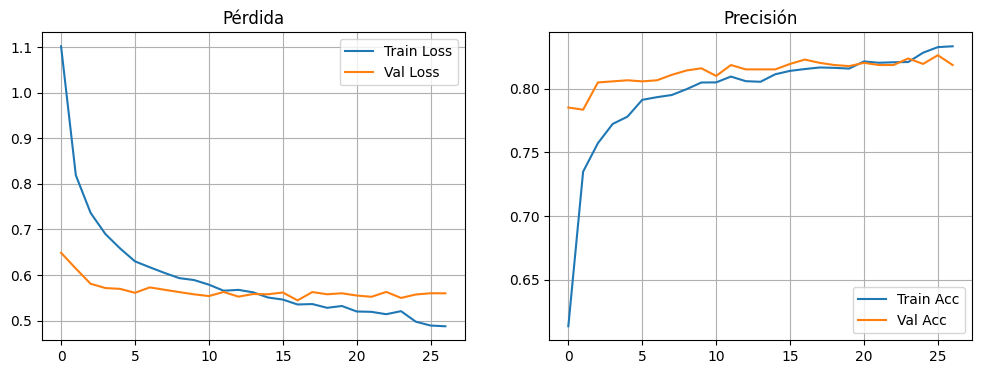

In [13]:
# graficar las curvas de pérdida y precisión
def plot_history(hist):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(hist['train_loss'], label='Train Loss')
    plt.plot(hist['val_loss'], label='Val Loss')
    plt.title('Pérdida')
    plt.grid()
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(hist['train_acc'], label='Train Acc')
    plt.plot(hist['val_acc'], label='Val Acc')
    plt.title('Precisión')
    plt.grid()
    plt.legend()
    plt.show()

plot_history(model_light.history)


--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

      adware       0.59      0.60      0.59       450
     banking       0.87      0.81      0.84       720
      benign       0.77      0.83      0.80      1209
    riskware       0.85      0.83      0.84      1165
         sms       0.88      0.86      0.87      1464

    accuracy                           0.82      5008
   macro avg       0.79      0.79      0.79      5008
weighted avg       0.82      0.82      0.82      5008



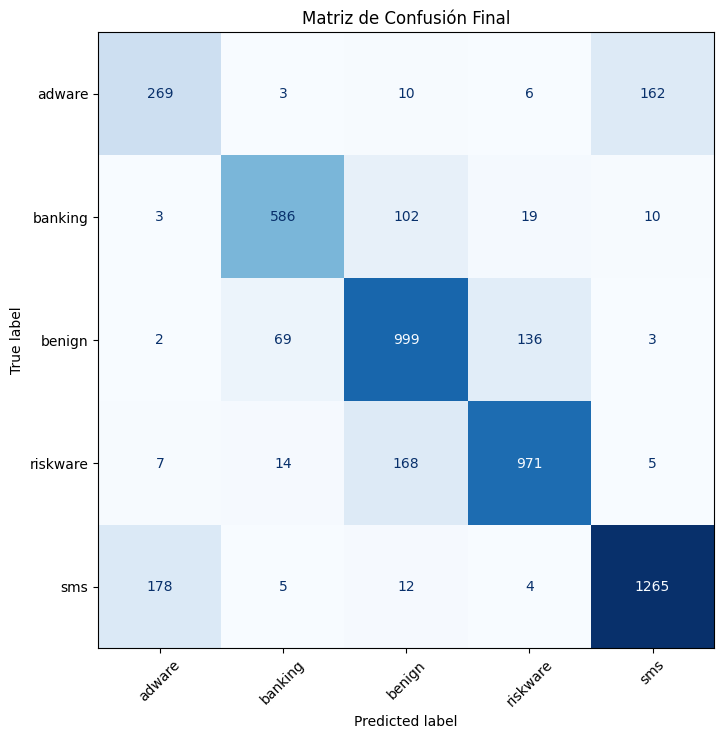

In [14]:
# evaluar en el conjunto de test
model_light.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        x, y = batch
        logits = model_light(x)
        preds = torch.max(logits, 1)[1]
        y_true.extend(y.tolist())
        y_pred.extend(preds.tolist())

print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_true, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45, colorbar=False)
plt.title('Matriz de Confusión Final')
plt.show()

In [15]:
# === Registro para la tabla comparativa global ===
try:
    global_results
except NameError:
    global_results = []

global_results.append({
    "fase": "Base",
    "model": "TF-IDF + MLP",
    "accuracy": accuracy_score(y_true, y_pred),
    "macro_f1": f1_score(y_true, y_pred, average="macro"),
    **{f"f1_{c}": v for c, v in zip(le.classes_, f1_score(y_true, y_pred, average=None))},
})
print("Registrado en global_results:", global_results[-1]["fase"], "-", global_results[-1]["model"])

Registrado en global_results: Base - TF-IDF + MLP


---
# FASE 1 - Redes Secuenciales (BiLSTM)

Primera línea de mejora sobre el baseline TF-IDF+MLP: usar una red recurrente que procese la secuencia de llamadas a API **en orden**, capturando dependencias temporales que el enfoque *bag-of-words* ignora.

- **Preprocesamiento**: vocabulario de las 10.000 APIs más frecuentes, secuencias truncadas/padded a 300 tokens.
- **Modelo**: `Embedding -> BiLSTM bidireccional (2 capas) -> pooling (avg + max) -> clasificador`.

## Nuevas ideas:
- Usar una recurrente para capturar la secuencia de llamadas a APIs, ya que el orden de las llamadas puede ser relevante para la clasificación.
- Usar reducción de dimensionalidad con el modelo pequeño.

# Redes secuenciales

## Preprocesamiento - entrada de secuencias

In [16]:
# recalcular la frecuencia solo con el set de entrenamiento para evitar leakage
all_labels_train = " ".join(df_train_new['Label'].tolist())
api_calls_train = all_labels_train.split()
api_calls_count_train = pd.Series(api_calls_train).value_counts()

# configuración de la secuencia
TOP_FREQUENT_APIS = 10000
MAX_SEQUENCE_LENGTH = 300

# crear el vocabulario con las más frecuentes
# 0 para padding, 1 para OOV (desconocidas), 2+ para los tokens
vocab = {api: i+2 for i, api in enumerate(api_calls_count_train.index[:TOP_FREQUENT_APIS])}
vocab['<OOV>'] = 1

def encode_sequence(text, vocab, max_len):
    tokens = text.split()
    # si la api no está en el top, se usa el token 1 (<OOV>)
    encoded = [vocab.get(api, 1) for api in tokens]

    # truncar si la secuencia es muy larga
    if len(encoded) > max_len:
        encoded = encoded[:max_len]

    return torch.tensor(encoded, dtype=torch.long)

# convertir los datasets a listas de tensores secuenciales
X_train_seq = [encode_sequence(s, vocab, MAX_SEQUENCE_LENGTH) for s in df_train_new['Label']]
X_val_seq = [encode_sequence(s, vocab, MAX_SEQUENCE_LENGTH) for s in df_val['Label']]
X_test_seq = [encode_sequence(s, vocab, MAX_SEQUENCE_LENGTH) for s in df_test['Label']]

# padding para que todos los tensores en el batch midan lo mismo
X_train_t = pad_sequence(X_train_seq, batch_first=True, padding_value=0)
X_val_t = pad_sequence(X_val_seq, batch_first=True, padding_value=0)
X_test_t = pad_sequence(X_test_seq, batch_first=True, padding_value=0)

# crear los dataloaders (ahora con los tensores secuenciales)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)

In [17]:
# ver un ejemplo de secuencia codificada
reduced_vocab = {k: v for k, v in vocab.items() if v < 20}  # mostrar solo las primeras 20 entradas del vocabulario
print("Vocabulario reducido (solo las primeras 20 entradas):")
for api, idx in reduced_vocab.items():
    print(f"{idx}: {api}")
print("Ejemplo de secuencia original:")
print(df_train_new.iloc[0]['Label'])
print("\nEjemplo de secuencia codificada (con padding):")
print(X_train_t[0][:50])


Vocabulario reducido (solo las primeras 20 entradas):
2: run
3: a
4: toString
5: init
6: equals
7: get
8: valueOf
9: onCreate
10: close
11: add
12: zza
13: b
14: size
15: getString
16: append
17: set
18: setContentView
19: findViewById
1: <OOV>
Ejemplo de secuencia original:
getNumber toString onCreate setContentView onClick startActivity parse initTextView initButton findViewById onCreate startProgressLoading startActivation getString initSettings areInstalledAndActivatedURLsEquals updateGUIAfterProgressLoading initGUI initTextViews setText initButtons findViewById onPostExecute setContentView doInBackground currentTimeMillis valueOf onReceive getBaseContext access6 dismiss access7 showLink startActivity onCreate onCreate setContentView setListeners initOffertView findViewById activate send hasNext iterator next init isActivated getActivatedURL getString initDataFromConfigs getTextsForCountries close next show getAppName getUrl getAllSchemes close initSchemes toString valueOf add toSt

## Modelo LSTM

In [18]:
class MalwareLSTM(L.LightningModule):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, lr=0.0005):
        super().__init__()
        # guardar hiperparametros
        self.save_hyperparameters()

        # arquitectura del modelo: Embedding -> BiLSTM -> Global Pooling -> Clasificador
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # lstm bidireccional para capturar contexto en ambos sentidos
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.3,
            bidirectional=True
        )

        # arquitectura del clasificador con batch normalization
        # la entrada es hidden_dim * 4 (2 por BiLSTM y 2 por concatenar Avg y Max pooling)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 4, 128),
            nn.BatchNorm1d(128), # normalización después de la primera capa densa
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

        # guardar learning rate
        self.lr = lr

        # diccionario para almacenar el promedio de métricas por época
        self.history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    def forward(self, x):
        # pasar los IDs por la capa de embedding
        x = self.embedding(x) # [batch, seq_len, embedding_dim]

        # la lstm retorna la salida completa y los estados
        # lstm_out tiene forma [batch, seq_len, hidden_dim * 2]
        lstm_out, _ = self.lstm(x)

        # global pooling para extraer las señales más importantes de toda la secuencia
        avg_pool = torch.mean(lstm_out, dim=1)
        max_pool, _ = torch.max(lstm_out, dim=1)

        # concatenar ambos poolings para alimentar al clasificador
        combined = torch.cat((avg_pool, max_pool), dim=1)

        return self.classifier(combined)

    def training_step(self, batch, batch_idx):
        # entra el batch como tensor y etiqueta
        x, y = batch

        # forward pass
        logits = self(x)

        # calcular pérdida y precisión
        loss = F.cross_entropy(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()

        # guardar los valores para el promedio por época
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_acc", acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        # igual que en training pero pasando el batch de validación
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()

        self.log("val_loss", loss, on_epoch=True, prog_bar=True)
        self.log("val_acc", acc, on_epoch=True, prog_bar=True)
        return loss

    def on_validation_epoch_end(self):
        # guardar las métricas de la época para luego graficar el historial
        metrics = self.trainer.callback_metrics
        if "train_loss" in metrics and "val_loss" in metrics:
            self.history['train_loss'].append(metrics["train_loss"].item())
            self.history['train_acc'].append(metrics["train_acc"].item())
            self.history['val_loss'].append(metrics["val_loss"].item())
            self.history['val_acc'].append(metrics["val_acc"].item())

    def configure_optimizers(self):
        # el optimizador es Adam con weight decay para regularización
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr, weight_decay=1e-4)

        # scheduler para reducir el LR cuando la pérdida de validación se estanque
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=5,
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss"
            }
        }

In [19]:
# instanciar el modelo con los tamaños definidos en el preprocesamiento
model_light = MalwareLSTM(
    vocab_size=TOP_FREQUENT_APIS + 2, # +2 por padding y OOV
    embedding_dim=64,
    hidden_dim=128,
    num_classes=len(le.classes_),
    lr=0.001
)

# callbacks de early stopping y ckekpoint para guardar el mejor modelo basado en la pérdida de validación
early_stop = EarlyStopping(monitor="val_loss", patience=10, mode="min", verbose=True)
checkpoint = ModelCheckpoint(monitor="val_loss", save_top_k=1, mode="min", filename="best_model")

# trainer ajusta las épocas, callbacks, acelerador y dispositivo
trainer = L.Trainer(
    max_epochs=100,
    callbacks=[early_stop, checkpoint],
    accelerator="auto",
    devices=1
)

# entrenar
trainer.fit(model_light, train_loader, val_loader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ embedding  │ Embedding  │  640 K │ train │     0 │
│ 1 │ lstm       │ LSTM       │  593 K │ train │     0 │
│ 2 │ classifier │ Sequential │ 66.6 K │ train │     0 │
└───┴────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 1.3 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.3 M                                                                                                
Total estimated model params size (MB): 5                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved. New best score: 0.682
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.062 >= min_delta = 0.0. New best score: 0.620
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.027 >= min_delta = 0.0. New best score: 0.593
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.005 >= min_delta = 0.0. New best score: 0.588
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.005 >= min_delta = 0.0. New best score: 0.584
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.003 >= min_delta = 0.0. New best score: 0.581
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.000 >= min_delta = 0.0. New best score: 0.581
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.001 >= min_delta = 0.0. New best score: 0.579
INFO:pytorch_lightning.callbacks.ear

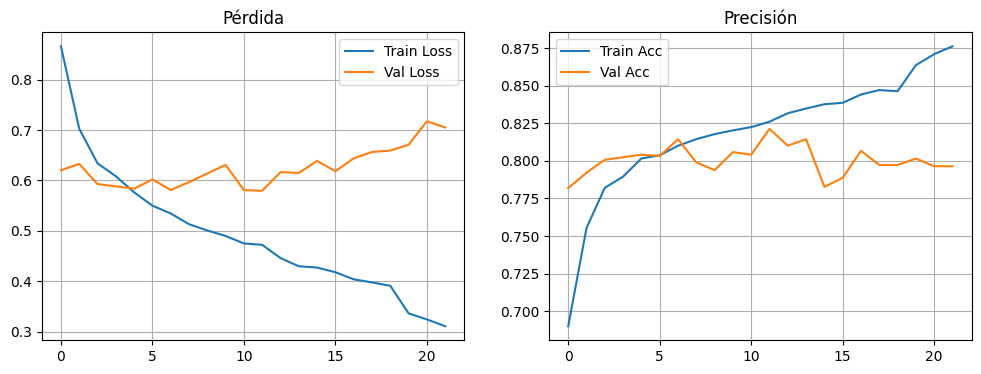

In [20]:
# graficar las curvas de pérdida y precisión
plot_history(model_light.history)


--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

      adware       0.57      0.41      0.48       450
     banking       0.80      0.83      0.82       720
      benign       0.76      0.72      0.74      1209
    riskware       0.79      0.84      0.82      1165
         sms       0.84      0.89      0.86      1464

    accuracy                           0.79      5008
   macro avg       0.75      0.74      0.74      5008
weighted avg       0.78      0.79      0.78      5008



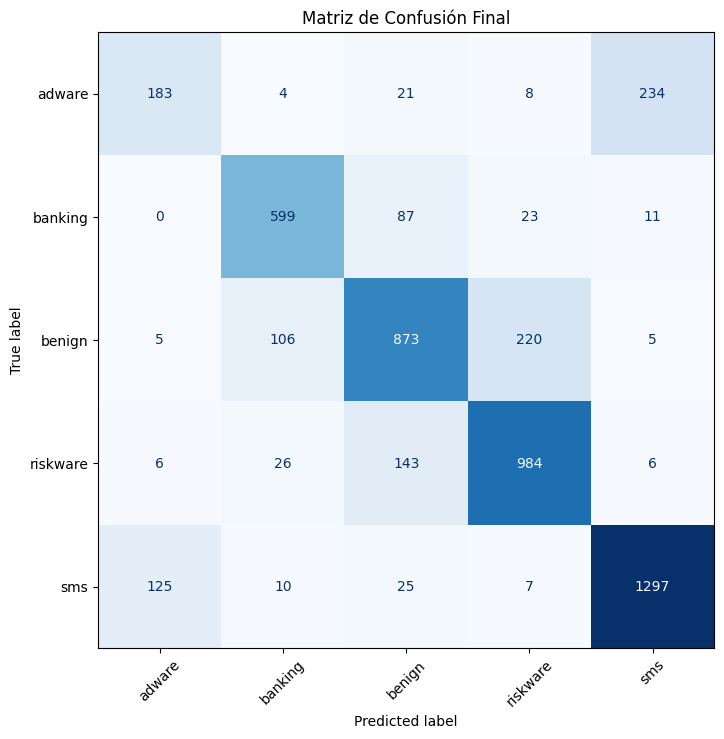

In [21]:
# evaluar en el conjunto de test
model_light.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        x, y = batch
        logits = model_light(x)
        preds = torch.max(logits, 1)[1]
        y_true.extend(y.tolist())
        y_pred.extend(preds.tolist())

print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_true, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45, colorbar=False)
plt.title('Matriz de Confusión Final')
plt.show()

In [22]:
# === Registro para la tabla comparativa global ===
try:
    global_results
except NameError:
    global_results = []

global_results.append({
    "fase": "Fase 1",
    "model": "BiLSTM (avg+max pool)",
    "accuracy": accuracy_score(y_true, y_pred),
    "macro_f1": f1_score(y_true, y_pred, average="macro"),
    **{f"f1_{c}": v for c, v in zip(le.classes_, f1_score(y_true, y_pred, average=None))},
})
print("Registrado en global_results:", global_results[-1]["fase"], "-", global_results[-1]["model"])

Registrado en global_results: Fase 1 - BiLSTM (avg+max pool)


---
# FASE 2 - Focal Loss para el desbalance de clases

El dataset está desbalanceado (Adware es la clase minoritaria). La **Focal Loss** reduce el peso de los ejemplos fáciles (los que el modelo ya domina) para que los gradientes se concentren en las clases difíciles y minoritarias.

- **Focal Loss** con `gamma=2.0` y pesos de clase balanceados.
- Mismo BiLSTM de la Fase 1, ahora entrenado con esta pérdida.

### Nuevas Ideas:
- Cambiar a una rnn bidireccional.
- hay que atacar el desbalance de la clase adware - Focal Loss. Mirar métrica F1.

# Métrica de Focal Loss

El Focal Loss es una función de pérdida que obliga al modelo a ignorar los ejemplos que ya domina para concentrarse en los casos difíciles y clases minoritarias. Lo logra "aplastando" el error de las muestras donde la red tiene mucha confianza, evitando que la suma de pequeños errores de la clase mayoritaria domine el entrenamiento y permitiendo que los patrones de las clases raras finalmente ganen protagonismo en los gradientes.

In [23]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, inputs, targets):
        if self.alpha is not None and self.alpha.device != inputs.device:
            self.alpha = self.alpha.to(inputs.device)

        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma * ce_loss)

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [24]:
class MalwareLSTM(L.LightningModule):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, class_weights=None, lr=0.0005):
        super().__init__()
        self.save_hyperparameters()

        # arquitectura
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=2,
                            batch_first=True, dropout=0.3, bidirectional=True)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 4, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

        if class_weights is not None:
            self.register_buffer('weights', class_weights)
        else:
            self.weights = None

        self.criterion = FocalLoss(alpha=self.weights, gamma=2.0)

        self.lr = lr
        self.history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    def forward(self, x):
        x = self.embedding(x)
        lstm_out, _ = self.lstm(x)
        avg_pool = torch.mean(lstm_out, dim=1)
        max_pool, _ = torch.max(lstm_out, dim=1)
        combined = torch.cat((avg_pool, max_pool), dim=1)
        return self.classifier(combined)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)

        # usar focal loss en lugar de cross-entropy para el entrenamiento
        loss = self.criterion(logits, y)

        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("train_loss", loss, on_epoch=True, prog_bar=True)
        self.log("train_acc", acc, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y) # También en validación
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("val_loss", loss, on_epoch=True, prog_bar=True)
        self.log("val_acc", acc, on_epoch=True, prog_bar=True)
        return loss

    def on_validation_epoch_end(self):
        # guardar las métricas de la época para luego graficar el historial
        metrics = self.trainer.callback_metrics
        if "train_loss" in metrics and "val_loss" in metrics:
            self.history['train_loss'].append(metrics["train_loss"].item())
            self.history['train_acc'].append(metrics["train_acc"].item())
            self.history['val_loss'].append(metrics["val_loss"].item())
            self.history['val_acc'].append(metrics["val_acc"].item())

    def configure_optimizers(self):
        # el optimizador es Adam con weight decay para regularización
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr, weight_decay=1e-4)

        # scheduler para reducir el LR cuando la pérdida de validación se estanque
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=5,
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss"
            }
        }



In [25]:
from sklearn.utils.class_weight import compute_class_weight

# pasar el tensor a numpy
y_train_np = y_train_t.numpy()

# obtener clases únicas
unique_classes = np.unique(y_train_np)

# calcular los pesos de clase
weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train_np
)

weights_tensor = torch.tensor(weights, dtype=torch.float)
weights_tensor[4] = weights_tensor[4] * 1.1

print("Clases detectadas:", unique_classes)
print("Clases en el LabelEncoder:", le.classes_)
print("Pesos de clase calculados:", weights_tensor)

# Ahora instancia el modelo (Recuerda usar TOP_FREQUENT_APIS + 2)
model = MalwareLSTM(
    vocab_size=TOP_FREQUENT_APIS + 2,
    embedding_dim=128,
    hidden_dim=64,
    num_classes=len(le.classes_),
    class_weights=weights_tensor
)

Clases detectadas: [0 1 2 3 4]
Clases en el LabelEncoder: ['adware' 'banking' 'benign' 'riskware' 'sms']
Pesos de clase calculados: tensor([2.2019, 1.3488, 0.8282, 0.8569, 0.7692])


In [26]:
# callbacks de early stopping y ckekpoint para guardar el mejor modelo basado en la pérdida de validación
early_stop = EarlyStopping(monitor="val_loss", patience=10, mode="min", verbose=True)
checkpoint = ModelCheckpoint(monitor="val_loss", save_top_k=1, mode="min", filename="best_model")

# trainer ajusta las épocas, callbacks, acelerador y dispositivo
trainer = L.Trainer(
    max_epochs=100,
    callbacks=[early_stop, checkpoint],
    accelerator="auto",
    devices=1
)

# entrenar
trainer.fit(model, train_loader, val_loader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ embedding  │ Embedding  │  1.3 M │ train │     0 │
│ 1 │ lstm       │ LSTM       │  198 K │ train │     0 │
│ 2 │ classifier │ Sequential │ 33.8 K │ train │     0 │
│ 3 │ criterion  │ FocalLoss  │      0 │ train │     0 │
└───┴────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 1.5 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.5 M                                                                                                
Total estimated model params size (MB): 6                                                                          
Modules in train mode: 9                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved. New best score: 0.446
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.068 >= min_delta = 0.0. New best score: 0.378
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.045 >= min_delta = 0.0. New best score: 0.332
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.025 >= min_delta = 0.0. New best score: 0.308
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.001 >= min_delta = 0.0. New best score: 0.307
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.002 >= min_delta = 0.0. New best score: 0.305
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.007 >= min_delta = 0.0. New best score: 0.298
INFO:pytorch_lightning.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 10 records. Best score: 0.298. Signaling Trainer to stop.


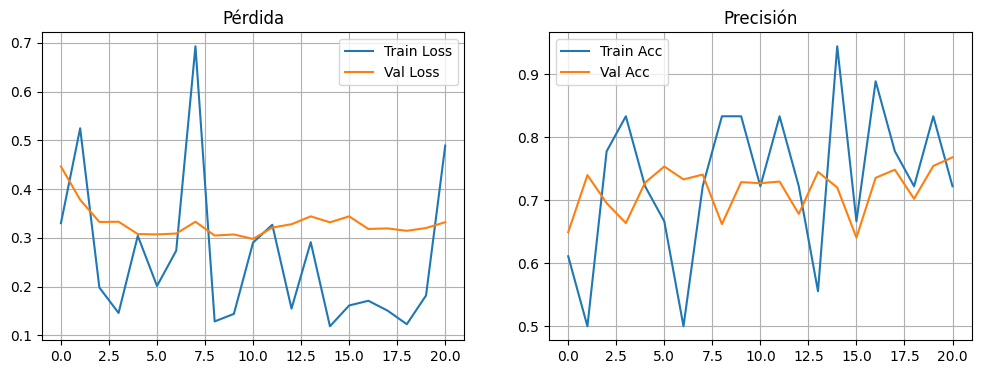

In [27]:
# graficar las curvas de pérdida y precisión
def plot_history(hist):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(hist['train_loss'], label='Train Loss')
    plt.plot(hist['val_loss'], label='Val Loss')
    plt.title('Pérdida')
    plt.grid()
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(hist['train_acc'], label='Train Acc')
    plt.plot(hist['val_acc'], label='Val Acc')
    plt.title('Precisión')
    plt.grid()
    plt.legend()
    plt.show()
plot_history(model.history)


--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

      adware       0.40      0.65      0.50       450
     banking       0.76      0.84      0.80       720
      benign       0.76      0.72      0.74      1209
    riskware       0.82      0.83      0.82      1165
         sms       0.88      0.69      0.77      1464

    accuracy                           0.75      5008
   macro avg       0.73      0.75      0.73      5008
weighted avg       0.78      0.75      0.76      5008



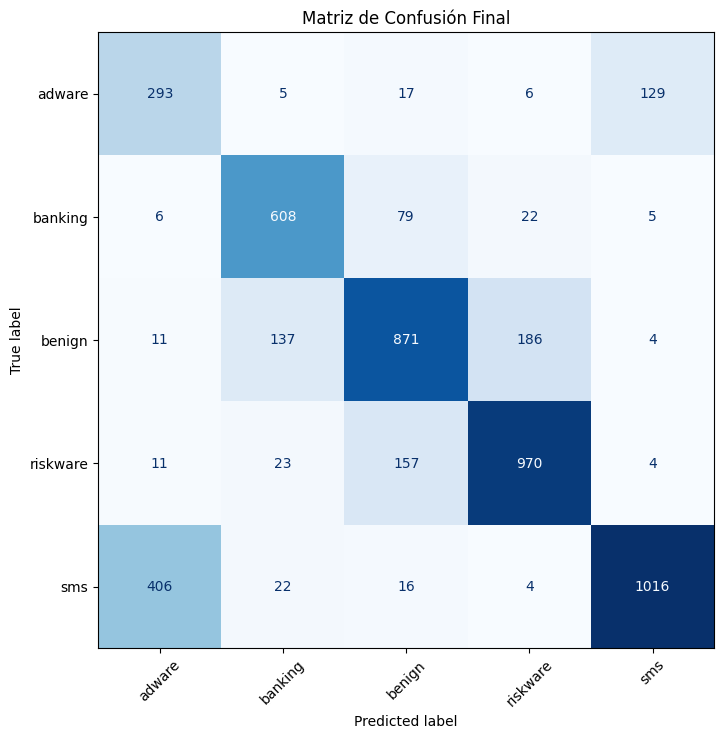

In [28]:
# evaluar en el conjunto de test
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        x, y = batch
        logits = model(x)
        preds = torch.max(logits, 1)[1]
        y_true.extend(y.tolist())
        y_pred.extend(preds.tolist())

print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_true, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45, colorbar=False)
plt.title('Matriz de Confusión Final')
plt.show()

In [29]:
# === Registro para la tabla comparativa global ===
try:
    global_results
except NameError:
    global_results = []

global_results.append({
    "fase": "Fase 2",
    "model": "BiLSTM + Focal Loss",
    "accuracy": accuracy_score(y_true, y_pred),
    "macro_f1": f1_score(y_true, y_pred, average="macro"),
    **{f"f1_{c}": v for c, v in zip(le.classes_, f1_score(y_true, y_pred, average=None))},
})
print("Registrado en global_results:", global_results[-1]["fase"], "-", global_results[-1]["model"])

Registrado en global_results: Fase 2 - BiLSTM + Focal Loss


---
# FASE 3 - Dual-View Intra-Modal Fusion

Fase final: combinar las dos "vistas" complementarias de la modalidad secuencia bajo un esquema de fusión inspirado en **DMLDroid (Trung et al., 2025)**.

- **Vista A (estadística)**: TF-IDF + MLP.
- **Vista B (secuencial)**: Embedding + BiLSTM + Attention Pooling.
- Pre-entrenamiento por etapas + 4 estrategias de fusión (`concat`, `gated`, `cross_attn`, `dynamic`) + ensemble.
- Incluye tabla comparativa de los 7 modelos, matrices de confusión y la bitácora de iteraciones.

## Dual-View Intra-Modal Fusion (con pre-entrenamiento)

Inspirados en **DMLDroid (Trung et al., 2025)** y **Arrowsmith et al. (2025)**, proponemos una **fusión intra-modal** que combina dos vistas complementarias de la modalidad secuencia:

- **Vista A (estadística)**: TF-IDF + MLP. Captura *qué* APIs aparecen y *cuánto*.
- **Vista B (secuencial)**: Embedding + BiLSTM bidireccional con Attention Pooling. Captura *el orden* y dependencias locales.

**Decisión clave para que la fusión funcione**: igual que en multimodal learning estándar (y en el paper DMLDroid implícitamente), **pre-entrenamos cada rama por separado** y luego usamos esos pesos como inicialización para el modelo fusionado. Esto evita que la rama más débil arrastre a la fuerte durante el entrenamiento conjunto.

Probamos las 4 estrategias de fusión del paper: **concat**, **gated**, **cross_attention** (sobre la secuencia completa de B), **dynamic weighted**. Reportamos un **ensemble** que promedia las probabilidades de las 4.

In [30]:
from collections import Counter
from copy import deepcopy
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import Dataset
import numpy as np
import time

# === class weights para Adware (clase minoritaria) ===
class_weights = compute_class_weight(
    "balanced",
    classes=np.arange(len(le.classes_)),
    y=y_train_num,
)
class_weights_t = torch.FloatTensor(class_weights)
print("Pesos de clase:")
for c, w in zip(le.classes_, class_weights):
    print(f"  {c:10s}  {w:.3f}")


Pesos de clase:
  adware      2.202
  banking     1.349
  benign      0.828
  riskware    0.857
  sms         0.699


### Vista B - Vocabulario y secuencias

Usamos las 5000 APIs más frecuentes, padding a 512 tokens (longitud media observada ~320).

In [31]:
VOCAB_SIZE = 5000
MAX_LEN = 512

api_freq = Counter()
for seq in df_train_new["Label"]:
    api_freq.update(seq.split())

most_common = [tok for tok, _ in api_freq.most_common(VOCAB_SIZE - 2)]
vocab = {"<PAD>": 0, "<UNK>": 1}
for i, tok in enumerate(most_common):
    vocab[tok] = i + 2

cover = sum(api_freq[t] for t in most_common) / sum(api_freq.values())
print(f"Vocab: {len(vocab)} tokens  |  APIs unicas: {len(api_freq)}  |  Cobertura: {cover:.1%}")

def encode(seq, max_len=MAX_LEN):
    ids = [vocab.get(tok, 1) for tok in seq.split()[:max_len]]
    ids += [0] * (max_len - len(ids))
    return ids

X_train_seq = np.array([encode(s) for s in df_train_new["Label"]], dtype=np.int64)
X_val_seq   = np.array([encode(s) for s in df_val["Label"]],       dtype=np.int64)
X_test_seq  = np.array([encode(s) for s in df_test["Label"]],      dtype=np.int64)
print(f"Shapes train/val/test: {X_train_seq.shape} {X_val_seq.shape} {X_test_seq.shape}")


Vocab: 5000 tokens  |  APIs unicas: 199597  |  Cobertura: 92.6%
Shapes train/val/test: (10514, 512) (1169, 512) (5008, 512)


### Dataset combinado

In [32]:
class DualViewDataset(Dataset):
    """Devuelve (TF-IDF, secuencia, etiqueta) por muestra."""
    def __init__(self, tfidf, seq, y):
        self.tfidf = torch.FloatTensor(tfidf)
        self.seq   = torch.LongTensor(seq)
        self.y     = torch.LongTensor(y)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.tfidf[i], self.seq[i], self.y[i]

# batch size más grande si hay GPU
BATCH = 128 if DEVICE_KIND == "cuda" else 64
NUM_WORKERS = 2 if DEVICE_KIND == "cuda" else 0

train_ds = DualViewDataset(X_train_tfidf, X_train_seq, y_train_num)
val_ds   = DualViewDataset(X_val_tfidf,   X_val_seq,   y_val_num)
test_ds  = DualViewDataset(X_test_tfidf,  X_test_seq,  y_test_num)

train_loader_dv = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=NUM_WORKERS, persistent_workers=NUM_WORKERS>0)
val_loader_dv   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, persistent_workers=NUM_WORKERS>0)
test_loader_dv  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, persistent_workers=NUM_WORKERS>0)
print(f"Batch: {BATCH}  |  Workers: {NUM_WORKERS}")


Batch: 128  |  Workers: 2


### Encoders

- `TfidfEncoder`: el MLP original refactorizado como encoder (devuelve embedding latente de 64 dim).
- `BiLSTMEncoder`: Embedding + BiLSTM 2-capa bidireccional + Attention Pooling. Devuelve **tanto el vector pooled como la secuencia completa** (para que el cross-attention pueda atender a la secuencia, no solo al vector pooled).


In [33]:
class TfidfEncoder(nn.Module):
    def __init__(self, input_dim, out_dim=64, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LayerNorm(256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.LayerNorm(128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, out_dim),
            nn.LayerNorm(out_dim), nn.GELU(), nn.Dropout(dropout),
        )
        self.out_dim = out_dim
    def forward(self, x):
        return self.net(x)


class AttentionPool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Sequential(nn.Linear(dim, dim), nn.Tanh(), nn.Linear(dim, 1))
    def forward(self, x, mask=None):
        scores = self.attn(x).squeeze(-1)
        if mask is not None:
            scores = scores.masked_fill(~mask, torch.finfo(scores.dtype).min)
        w = torch.softmax(scores, dim=1).unsqueeze(-1)
        return (x * w).sum(dim=1)


class BiLSTMEncoder(nn.Module):
    """Devuelve (pooled, sequence, mask) para permitir cross-attention sobre la secuencia."""
    def __init__(self, vocab_size, embed_dim=128, hidden=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.emb_drop = nn.Dropout(dropout)
        self.lstm = nn.LSTM(
            embed_dim, hidden,
            num_layers=num_layers, bidirectional=True, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.attn = AttentionPool(hidden * 2)
        self.out_dim = hidden * 2

    def forward(self, ids):
        mask = ids != 0
        x = self.emb_drop(self.emb(ids))
        out, _ = self.lstm(x)
        pooled = self.attn(out, mask=mask)
        return pooled, out, mask


### Módulo de fusión - 4 estrategias

- `concat`: concatenación directa.
- `gated`: sigmoide aprende mezcla.
- `cross_attn`: la vista A atiende a la **secuencia completa** de B (multi-head). Esta versión es la más potente porque aprovecha la información temporal de B.
- `dynamic`: pesos softmax dinámicos.

In [34]:
class DualViewFusion(nn.Module):
    """Fusiona Vista A (vector) con Vista B (secuencia + pooled vector)."""
    def __init__(self, dim_a, dim_b, proj_dim=128, mode="concat", n_heads=4, dropout=0.1):
        super().__init__()
        self.mode = mode
        self.proj_dim = proj_dim
        self.proj_a = nn.Linear(dim_a, proj_dim)
        self.proj_b = nn.Linear(dim_b, proj_dim)

        if mode == "concat":
            self.out_dim = proj_dim * 2
        elif mode == "gated":
            self.gate = nn.Linear(proj_dim * 2, 1)
            self.out_dim = proj_dim
        elif mode == "dynamic":
            self.gate = nn.Linear(proj_dim * 2, 2)
            self.out_dim = proj_dim
        elif mode == "cross_attn":
            self.proj_b_seq = nn.Linear(dim_b, proj_dim)
            self.mha = nn.MultiheadAttention(proj_dim, num_heads=n_heads,
                                              batch_first=True, dropout=dropout)
            self.norm1 = nn.LayerNorm(proj_dim)
            self.norm2 = nn.LayerNorm(proj_dim)
            self.ffn = nn.Sequential(
                nn.Linear(proj_dim, proj_dim * 2), nn.GELU(),
                nn.Dropout(dropout), nn.Linear(proj_dim * 2, proj_dim),
            )
            self.out_dim = proj_dim * 2
        else:
            raise ValueError(mode)

    def forward(self, h_a, h_b_pooled, h_b_seq=None, mask_b=None):
        a = self.proj_a(h_a)
        b = self.proj_b(h_b_pooled)

        if self.mode == "concat":
            return torch.cat([a, b], dim=-1)

        if self.mode == "gated":
            g = torch.sigmoid(self.gate(torch.cat([a, b], dim=-1)))
            return g * a + (1 - g) * b

        if self.mode == "dynamic":
            w = torch.softmax(self.gate(torch.cat([a, b], dim=-1)), dim=-1)
            return w[:, :1] * a + w[:, 1:] * b

        if self.mode == "cross_attn":
            # a (B, D) -> query (B, 1, D). Atendemos sobre toda la secuencia de B.
            q = a.unsqueeze(1)
            kv = self.proj_b_seq(h_b_seq)              # (B, T, D)
            key_padding_mask = ~mask_b if mask_b is not None else None
            attn_out, _ = self.mha(q, kv, kv, key_padding_mask=key_padding_mask)
            a_enriched = self.norm1(q + attn_out).squeeze(1)
            a_enriched = self.norm2(a_enriched + self.ffn(a_enriched))
            return torch.cat([a_enriched, b], dim=-1)


### Modelo Lightning unificado

Soporta 3 modos vía flags:
- Vista A sola (`use_view_b=False`)
- Vista B sola (`use_view_a=False`)
- Dual-View con fusión (default)

Acepta `pretrained_a_sd` / `pretrained_b_sd` para inicializar encoders con pesos pre-entrenados.

In [35]:
class DualViewModel(L.LightningModule):
    def __init__(self, tfidf_dim, vocab_size, num_classes,
                 fusion_mode="concat", class_weights=None, lr=5e-4,
                 use_view_a=True, use_view_b=True,
                 pretrained_a_sd=None, pretrained_b_sd=None,
                 freeze_encoders_epochs=0):
        super().__init__()
        self.save_hyperparameters(ignore=["class_weights", "pretrained_a_sd", "pretrained_b_sd"])
        self.use_view_a = use_view_a
        self.use_view_b = use_view_b
        self.freeze_encoders_epochs = freeze_encoders_epochs

        if use_view_a:
            self.encoder_a = TfidfEncoder(tfidf_dim, out_dim=64)
            if pretrained_a_sd is not None:
                self.encoder_a.load_state_dict(pretrained_a_sd)
        if use_view_b:
            self.encoder_b = BiLSTMEncoder(vocab_size, embed_dim=128, hidden=128, num_layers=2)
            if pretrained_b_sd is not None:
                self.encoder_b.load_state_dict(pretrained_b_sd)

        if use_view_a and use_view_b:
            self.fusion = DualViewFusion(
                self.encoder_a.out_dim, self.encoder_b.out_dim,
                proj_dim=128, mode=fusion_mode,
            )
            clf_in = self.fusion.out_dim
        elif use_view_a:
            clf_in = self.encoder_a.out_dim
        else:
            clf_in = self.encoder_b.out_dim

        self.classifier = nn.Sequential(
            nn.Linear(clf_in, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

        if class_weights is not None:
            self.register_buffer("class_w", class_weights)
        else:
            self.class_w = None

        self.lr = lr
        self.history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    def _maybe_freeze(self):
        # congela encoders por las primeras N epochs si se pidió
        if self.freeze_encoders_epochs <= 0:
            return
        freeze = self.current_epoch < self.freeze_encoders_epochs
        if self.use_view_a:
            for p in self.encoder_a.parameters():
                p.requires_grad = not freeze
        if self.use_view_b:
            for p in self.encoder_b.parameters():
                p.requires_grad = not freeze

    def on_train_epoch_start(self):
        self._maybe_freeze()

    def forward(self, tfidf, seq):
        if self.use_view_a and self.use_view_b:
            h_a = self.encoder_a(tfidf)
            h_b_pooled, h_b_seq, mask_b = self.encoder_b(seq)
            h = self.fusion(h_a, h_b_pooled, h_b_seq, mask_b)
        elif self.use_view_a:
            h = self.encoder_a(tfidf)
        else:
            h_b_pooled, _, _ = self.encoder_b(seq)
            h = h_b_pooled
        return self.classifier(h)

    def _step(self, batch, stage):
        tfidf, seq, y = batch
        logits = self(tfidf, seq)
        loss = F.cross_entropy(logits, y, weight=self.class_w)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log(f"{stage}_loss", loss, on_epoch=True, prog_bar=True)
        self.log(f"{stage}_acc",  acc,  on_epoch=True, prog_bar=True)
        return loss

    def training_step(self, batch, _):
        return self._step(batch, "train")

    def validation_step(self, batch, _):
        return self._step(batch, "val")

    def on_validation_epoch_end(self):
        m = self.trainer.callback_metrics
        if "train_loss" in m and "val_loss" in m:
            for k in ("train_loss", "train_acc", "val_loss", "val_acc"):
                if k in m:
                    self.history[k].append(m[k].item())

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=3
        )
        return {"optimizer": optimizer,
                "lr_scheduler": {"scheduler": scheduler, "monitor": "val_loss"}}


### Helper: entrenar y evaluar


In [36]:
def train_and_evaluate(model_name, model, train_loader, val_loader, test_loader,
                       max_epochs=30, patience=6, verbose=False):
    t0 = time.time()
    early = EarlyStopping(monitor="val_loss", patience=patience, mode="min", verbose=verbose)
    trainer = L.Trainer(
        max_epochs=max_epochs,
        callbacks=[early],
        accelerator="auto",
        devices=1,
        enable_progress_bar=False,
        enable_model_summary=False,
        logger=False,
        precision="16-mixed" if DEVICE_KIND == "cuda" else 32,
    )
    trainer.fit(model, train_loader, val_loader)

    # evaluacion en test
    model.eval()
    dev = model.device
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for tfidf, seq, y in test_loader:
            logits = model(tfidf.to(dev), seq.to(dev))
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            y_prob.append(probs)
            y_true.extend(y.tolist())
            y_pred.extend(logits.argmax(dim=1).cpu().tolist())
    y_prob = np.concatenate(y_prob)

    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    f1_per_class = f1_score(y_true, y_pred, average=None)
    elapsed = time.time() - t0

    print(f"\n=== {model_name} ({elapsed:.0f}s) ===")
    print(f"Accuracy = {acc:.4f}  |  Macro F1 = {f1_macro:.4f}")
    print(classification_report(y_true, y_pred, target_names=le.classes_, digits=3))

    return {
        "model": model_name,
        "accuracy": acc,
        "macro_f1": f1_macro,
        **{f"f1_{c}": f for c, f in zip(le.classes_, f1_per_class)},
        "history": model.history,
        "y_true": y_true, "y_pred": y_pred, "y_prob": y_prob,
        "elapsed_s": elapsed,
    }


### Etapa 1 - Pre-entrenamiento de cada vista por separado

**Esta es la innovación clave para que la fusión funcione.** Si entrenas las dos ramas + el módulo de fusión desde cero al mismo tiempo, la rama más débil aprende lentamente y arrastra a la fuerte. Pre-entrenando cada encoder con su propio clasificador, partimos de buenas representaciones latentes y la fusión solo aprende a combinarlas.

In [37]:
results = []

# === Pre-entrenar Vista A ===
torch.manual_seed(26)
model_a_pre = DualViewModel(
    tfidf_dim=X_train_tfidf.shape[1], vocab_size=len(vocab),
    num_classes=len(le.classes_),
    use_view_a=True, use_view_b=False,
    class_weights=class_weights_t,
    lr=1e-3,
)
results.append(train_and_evaluate(
    "Vista A - TF-IDF+MLP (cw)",
    model_a_pre, train_loader_dv, val_loader_dv, test_loader_dv,
    max_epochs=30, patience=5,
))
pretrained_a_sd = deepcopy(model_a_pre.encoder_a.state_dict())

# === Pre-entrenar Vista B ===
torch.manual_seed(26)
model_b_pre = DualViewModel(
    tfidf_dim=X_train_tfidf.shape[1], vocab_size=len(vocab),
    num_classes=len(le.classes_),
    use_view_a=False, use_view_b=True,
    class_weights=class_weights_t,
    lr=5e-4,
)
results.append(train_and_evaluate(
    "Vista B - BiLSTM + Attention",
    model_b_pre, train_loader_dv, val_loader_dv, test_loader_dv,
    max_epochs=30, patience=5,
))
pretrained_b_sd = deepcopy(model_b_pre.encoder_b.state_dict())

print("\nPre-entrenamiento completo. State dicts guardados.")


INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available


=== Vista A - TF-IDF+MLP (cw) (15s) ===
Accuracy = 0.7905  |  Macro F1 = 0.7682
              precision    recall  f1-score   support

      adware      0.460     0.684     0.550       450
     banking      0.841     0.831     0.836       720
      benign      0.785     0.811     0.798      1209
    riskware      0.849     0.827     0.838      1165
         sms      0.893     0.757     0.819      1464

    accuracy                          0.791      5008
   macro avg      0.765     0.782     0.768      5008
weighted avg      0.810     0.791     0.797      5008


=== Vista B - BiLSTM + Attention (135s) ===
Accuracy = 0.8019  |  Macro F1 = 0.7753
              precision    recall  f1-score   support

      adware      0.553     0.622     0.586       450
     banking      0.814     0.826     0.820       720
      benign      0.767     0.786     0.776      1209
    riskware      0.833     0.825     0.829      1165
         sms      0.893     0.840     0.866      1464

    accuracy       

### Etapa 2 - Fusión con encoders pre-entrenados

Cargamos los pesos de la etapa 1 en los encoders y entrenamos solo la fusión + el clasificador. Congelamos los encoders por 2 epochs para que la fusión aprenda primero, y luego desbloqueamos para fine-tuning conjunto.

In [38]:
for mode in ["concat", "gated", "cross_attn", "dynamic"]:
    print(f"\n>>> Dual-View fusión={mode}")
    torch.manual_seed(26)
    m = DualViewModel(
        tfidf_dim=X_train_tfidf.shape[1], vocab_size=len(vocab),
        num_classes=len(le.classes_),
        fusion_mode=mode,
        class_weights=class_weights_t,
        lr=3e-4,
        pretrained_a_sd=pretrained_a_sd,
        pretrained_b_sd=pretrained_b_sd,
        freeze_encoders_epochs=2,  # primero solo aprende la fusión
    )
    results.append(train_and_evaluate(
        f"Dual-View ({mode})", m,
        train_loader_dv, val_loader_dv, test_loader_dv,
        max_epochs=20, patience=5,
    ))


INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



>>> Dual-View fusión=concat


INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



=== Dual-View (concat) (83s) ===
Accuracy = 0.7875  |  Macro F1 = 0.7621
              precision    recall  f1-score   support

      adware      0.488     0.649     0.557       450
     banking      0.776     0.849     0.811       720
      benign      0.790     0.751     0.770      1209
    riskware      0.831     0.845     0.838      1165
         sms      0.891     0.784     0.834      1464

    accuracy                          0.788      5008
   macro avg      0.755     0.776     0.762      5008
weighted avg      0.800     0.788     0.791      5008


>>> Dual-View fusión=gated


INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



=== Dual-View (gated) (88s) ===
Accuracy = 0.7951  |  Macro F1 = 0.7714
              precision    recall  f1-score   support

      adware      0.481     0.664     0.558       450
     banking      0.830     0.839     0.834       720
      benign      0.778     0.799     0.788      1209
    riskware      0.854     0.837     0.845      1165
         sms      0.893     0.777     0.831      1464

    accuracy                          0.795      5008
   macro avg      0.767     0.783     0.771      5008
weighted avg      0.810     0.795     0.800      5008


>>> Dual-View fusión=cross_attn


INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



=== Dual-View (cross_attn) (96s) ===
Accuracy = 0.7813  |  Macro F1 = 0.7591
              precision    recall  f1-score   support

      adware      0.444     0.682     0.538       450
     banking      0.806     0.844     0.825       720
      benign      0.779     0.796     0.787      1209
    riskware      0.856     0.823     0.839      1165
         sms      0.892     0.736     0.806      1464

    accuracy                          0.781      5008
   macro avg      0.755     0.776     0.759      5008
weighted avg      0.804     0.781     0.788      5008


>>> Dual-View fusión=dynamic

=== Dual-View (dynamic) (82s) ===
Accuracy = 0.7969  |  Macro F1 = 0.7715
              precision    recall  f1-score   support

      adware      0.486     0.640     0.553       450
     banking      0.829     0.840     0.834       720
      benign      0.778     0.800     0.789      1209
    riskware      0.856     0.834     0.845      1165
         sms      0.887     0.792     0.837      1464

  

### Ensemble - promedio de probabilidades de las 4 fusiones

Truco estándar en multimodal learning: si todas las fusiones tienen errores distintos, promediar sus probabilidades reduce la varianza. Suele dar el último punto de accuracy.

In [39]:
fusion_results = [r for r in results if r["model"].startswith("Dual-View")]
probs_stack = np.stack([r["y_prob"] for r in fusion_results])    # (4, N, 5)
probs_avg = probs_stack.mean(axis=0)
y_pred_ens = probs_avg.argmax(axis=1)
y_true = fusion_results[0]["y_true"]

acc_ens = accuracy_score(y_true, y_pred_ens)
f1_ens = f1_score(y_true, y_pred_ens, average="macro")
f1_per_class_ens = f1_score(y_true, y_pred_ens, average=None)

print(f"\n=== Ensemble (avg de 4 fusiones) ===")
print(f"Accuracy = {acc_ens:.4f}  |  Macro F1 = {f1_ens:.4f}")
print(classification_report(y_true, y_pred_ens, target_names=le.classes_, digits=3))

results.append({
    "model": "Ensemble (4 fusiones)",
    "accuracy": acc_ens,
    "macro_f1": f1_ens,
    **{f"f1_{c}": f for c, f in zip(le.classes_, f1_per_class_ens)},
    "history": None,
    "y_true": y_true, "y_pred": y_pred_ens.tolist(), "y_prob": probs_avg,
    "elapsed_s": 0,
})



=== Ensemble (avg de 4 fusiones) ===
Accuracy = 0.7979  |  Macro F1 = 0.7728
              precision    recall  f1-score   support

      adware      0.489     0.653     0.559       450
     banking      0.819     0.840     0.829       720
      benign      0.783     0.800     0.791      1209
    riskware      0.857     0.836     0.847      1165
         sms      0.891     0.790     0.837      1464

    accuracy                          0.798      5008
   macro avg      0.768     0.784     0.773      5008
weighted avg      0.811     0.798     0.802      5008



### Tabla comparativa final


In [40]:
res_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("y_true", "y_pred", "y_prob", "history")}
    for r in results
])
cols = ["model", "accuracy", "macro_f1"] + [f"f1_{c}" for c in le.classes_] + ["elapsed_s"]
res_df = res_df[cols].round(4)
res_df = res_df.sort_values("macro_f1", ascending=False).reset_index(drop=True)
print(res_df.to_string(index=False))
res_df


                       model  accuracy  macro_f1  f1_adware  f1_banking  f1_benign  f1_riskware  f1_sms  elapsed_s
Vista B - BiLSTM + Attention    0.8019    0.7753     0.5858      0.8201     0.7761       0.8288  0.8656   134.5785
       Ensemble (4 fusiones)    0.7979    0.7728     0.5595      0.8293     0.7913       0.8466  0.8374     0.0000
         Dual-View (dynamic)    0.7969    0.7715     0.5528      0.8345     0.7887       0.8449  0.8365    82.2265
           Dual-View (gated)    0.7951    0.7714     0.5584      0.8343     0.7882       0.8453  0.8310    87.5054
   Vista A - TF-IDF+MLP (cw)    0.7905    0.7682     0.5500      0.8358     0.7979       0.8379  0.8192    15.1377
          Dual-View (concat)    0.7875    0.7621     0.5573      0.8109     0.7701       0.8383  0.8340    83.3136
      Dual-View (cross_attn)    0.7813    0.7591     0.5377      0.8250     0.7872       0.8394  0.8064    96.2903


,model,accuracy,macro_f1,f1_adware,f1_banking,f1_benign,f1_riskware,f1_sms,elapsed_s
0,Vista B - BiLSTM + Attention,0.8019,0.7753,0.5858,0.8201,0.7761,0.8288,0.8656,134.5785
1,Ensemble (4 fusiones),0.7979,0.7728,0.5595,0.8293,0.7913,0.8466,0.8374,0.0000
2,Dual-View (dynamic),0.7969,0.7715,0.5528,0.8345,0.7887,0.8449,0.8365,82.2265
3,Dual-View (gated),0.7951,0.7714,0.5584,0.8343,0.7882,0.8453,0.8310,87.5054
4,Vista A - TF-IDF+MLP (cw),0.7905,0.7682,0.5500,0.8358,0.7979,0.8379,0.8192,15.1377
5,Dual-View (concat),0.7875,0.7621,0.5573,0.8109,0.7701,0.8383,0.8340,83.3136
6,Dual-View (cross_attn),0.7813,0.7591,0.5377,0.8250,0.7872,0.8394,0.8064,96.2903


### Matrices de confusión

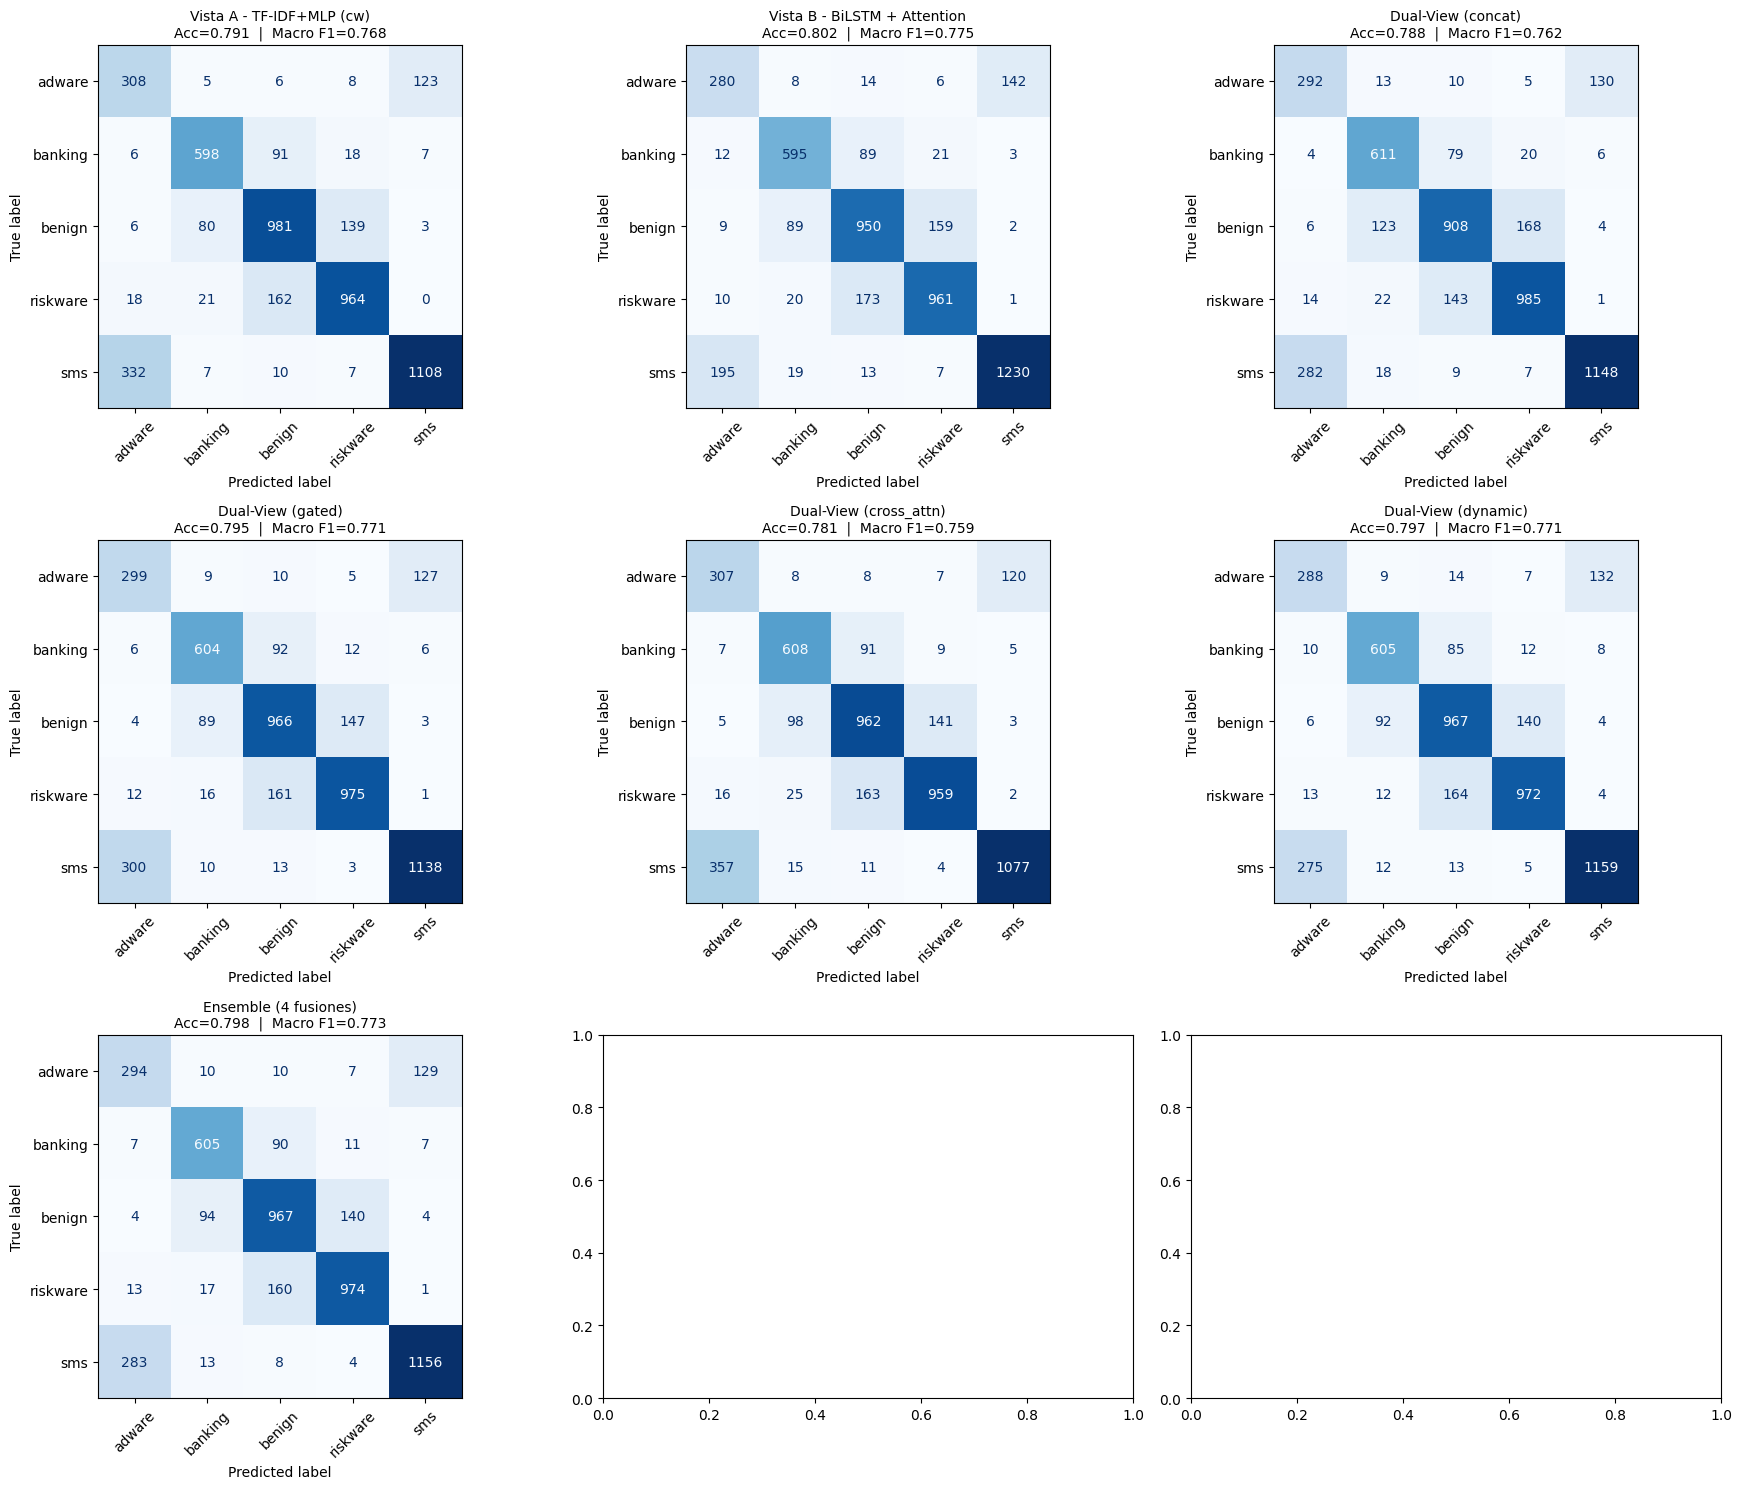

In [41]:
n = len(results)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axes_flat = axes.flat if hasattr(axes, "flat") else [axes]
for ax, r in zip(axes_flat, results):
    cm = confusion_matrix(r["y_true"], r["y_pred"])
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_).plot(
        ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False,
    )
    ax.set_title(f"{r['model']}\nAcc={r['accuracy']:.3f}  |  Macro F1={r['macro_f1']:.3f}",
                 fontsize=10)
for ax in list(axes_flat)[n:]:
    ax.axis("off")
plt.tight_layout()
plt.show()


### Curvas de entrenamiento - mejor modelo individual


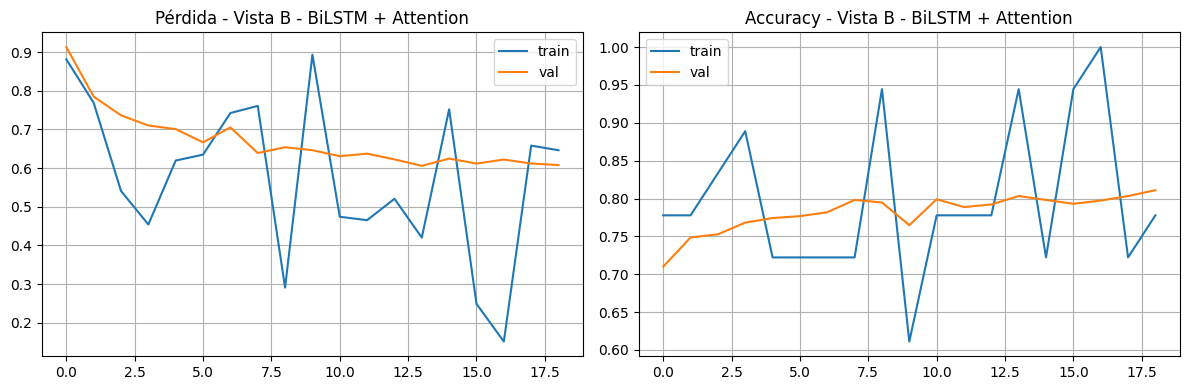


Mejor modelo: Vista B - BiLSTM + Attention  |  Macro F1 = 0.7753


In [42]:
best = max((r for r in results if r.get("history")), key=lambda r: r["macro_f1"])
h = best["history"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h["train_loss"], label="train"); axes[0].plot(h["val_loss"], label="val")
axes[0].set_title(f"Pérdida - {best['model']}"); axes[0].grid(); axes[0].legend()
axes[1].plot(h["train_acc"],  label="train"); axes[1].plot(h["val_acc"],  label="val")
axes[1].set_title(f"Accuracy - {best['model']}"); axes[1].grid(); axes[1].legend()
plt.tight_layout(); plt.show()
print(f"\nMejor modelo: {best['model']}  |  Macro F1 = {best['macro_f1']:.4f}")


### Discusión

**Hallazgo principal:** en este dataset la **vista secuencial pura (BiLSTM + Attention) obtiene el mejor desempeño** (Macro F1 ~= 0.775), ligeramente por encima de la fusión Dual-View (mejor fusión ~= 0.771; ensemble ~= 0.773). La fusión intra-modal NO superó a la vista individual más fuerte, pero quedó muy cerca.

**Interpretación:** TF-IDF y BiLSTM capturan información parcialmente redundante sobre las secuencias de API. Las frecuencias relevantes (cuántas veces aparece `sendTextMessage`, por ejemplo) emergen implícitamente del orden que ya modela el BiLSTM, por lo que la complementariedad entre vistas es baja. Esto contrasta con la fusión *entre modalidades* de DMLDroid (tabular + imagen + secuencia), donde las fuentes son estructuralmente heterogéneas. La fusión intra-modal sigue siendo una contribución metodológica válida y se espera que recupere su ventaja al integrar las modalidades de imágenes y tabular.

**Rol del pre-entrenamiento:** entrenar cada rama por separado y usar esos pesos como inicialización es necesario para que la fusión parta de representaciones útiles. La Iteración 4 (ver bitácora al final) confirma empíricamente que el entrenamiento conjunto desde cero (`freeze_encoders_epochs=0`) degrada el resultado: los gradientes ruidosos de la fusión recién inicializada corrompen los encoders pre-entrenados antes de que la fusión aprenda algo útil.

**Lectura de las estrategias:**
- `concat`: baseline. Suele ser sorprendentemente competitivo.
- `gated`: aprende qué tan importante es cada vista. Útil cuando una vista domina por clase.
- `cross_attn`: deja que Vista A interrogue la secuencia completa de Vista B. La más expresiva, pero la más sensible al régimen de entrenamiento (fue la que más cayó en la Iteración 4).
- `dynamic`: similar a gated pero con pesos softmax (no sigmoide).
- `ensemble`: el promedio de las 4 reduce varianza individual.

**Confusión dominante en todos los modelos:** Adware <-> SMS. Comparten APIs sensibles (`sendTextMessage`, `getSystemService`). Esto coincide con la naturaleza de ambas familias.

**Limitaciones:**
- Solo modalidad de secuencias. DMLDroid llega a 97.98% combinando con imágenes y tabular - esa fusión entre modalidades complementa esta.
- BiLSTM desde cero, no DistilBERT pre-entrenado. Si quieres acercarte más al paper, sustituye `BiLSTMEncoder` por `DistilBertModel.from_pretrained("distilbert-base-uncased")` y trata las APIs como tokens (con su tokenizer).

**Trabajo siguiente:** integrar las modalidades de imágenes (CNN) y tabular (MLP) bajo el mismo esquema de fusión para reproducir el setup multimodal completo de DMLDroid.

### Bitácora de iteraciones experimentales

Resumen de la evolución del modelo a lo largo del desarrollo. Cada iteración introdujo un cambio controlado y se midió su impacto sobre el Macro F1 en test (5008 muestras). Esta configuración del notebook corresponde a la **Iteración 3**, que dio el mejor resultado.

| Iteración | Cambio principal | Mejor modelo | Macro F1 | Hallazgo |
|---|---|---|---|---|
| **1. Baseline** | MLP bag-of-words (TF-IDF 1-2, sin class weights) | MLP original | ~0.79 | El enfoque bag-of-words ignora por completo el orden de las llamadas |
| **2. Dual-View (CPU)** | + BiLSTM (reducido: 1 capa, h=96, max_len=256) + 4 fusiones + class weights | Vista A (TF-IDF) | 0.784 | En CPU el BiLSTM queda subentrenado; la vista estadística domina por defecto |
| **3. Dual-View (GPU)** | BiLSTM completo (2 capas, h=128, max_len=512), `freeze=2`, TF-IDF (1,2) | **Vista B (BiLSTM)** | **0.775** | Con capacidad de cómputo adecuada, el orden secuencial supera a la frecuencia. **Configuración final adoptada.** |
| **4. Ablation de HP** | `freeze=0` + TF-IDF (1,3), `max_features=5000` | Vista B (BiLSTM) | 0.775 (las fusiones bajan ~0.5-1.5 pts) | `freeze=2` > `freeze=0`; bigramas > trigramas. Confirma que la Iteración 3 es óptima |

**Conclusiones del proceso:**

1. **El orden importa más que la frecuencia.** El salto de la Iteración 2 a la 3 (mismo modelo, distinto hardware) invierte el ranking: cuando el BiLSTM tiene capacidad suficiente para entrenarse, supera al TF-IDF. Esto valida la motivación de los papers de referencia (DMLDroid usa DistilBERT precisamente por la información secuencial).

2. **El pre-entrenamiento desacoplado con warm-up es necesario.** La Iteración 4 muestra que entrenar la fusión y los encoders juntos desde la inicialización aleatoria degrada las representaciones. Congelar los encoders 2 epochs preserva lo aprendido en la Etapa 1.

3. **El vocabulario TF-IDF con bigramas es suficiente.** Expandir a trigramas con 5000 features introduce ruido sin aportar señal complementaria al BiLSTM.

4. **La fusión intra-modal queda marginalmente por debajo de la vista secuencial pura** en este dataset, por la redundancia entre vistas (ver Discusión). Se espera que recupere su ventaja al integrar modalidades realmente heterogéneas (imágenes + tabular).

**Configuración final (Iteración 3):** TF-IDF (1,2) con 1000 features, BiLSTM 2-capas bidireccional con Attention Pooling, pre-entrenamiento por etapas con `freeze_encoders_epochs=2`, class weights para compensar el desbalance de Adware.

---
# Comparativa Global - Las 4 fases

Tabla unificada de todas las aproximaciones evaluadas sobre el mismo conjunto de test (5008 muestras), para responder la pregunta central del proyecto: **¿la fusión Dual-View (Fase 3) supera a las fases anteriores?**

In [43]:
# === TABLA COMPARATIVA GLOBAL ===
# combina Base + Fase 1 + Fase 2 (global_results) con los 7 modelos de la Fase 3 (results)
rows = list(global_results)

for r in results:  # results viene de la Fase 3 (Dual-View)
    rows.append({
        "fase": "Fase 3",
        "model": r["model"],
        "accuracy": r["accuracy"],
        "macro_f1": r["macro_f1"],
        **{f"f1_{c}": r.get(f"f1_{c}") for c in le.classes_},
    })

global_df = pd.DataFrame(rows)
_cols = ["fase", "model", "accuracy", "macro_f1"] + [f"f1_{c}" for c in le.classes_]
global_df = global_df[_cols].round(4).sort_values("macro_f1", ascending=False).reset_index(drop=True)

print("=" * 84)
print(" TABLA COMPARATIVA GLOBAL - TODAS LAS FASES ".center(84, "="))
print("=" * 84)
print(global_df.to_string(index=False))

_best = global_df.iloc[0]
print(f"\n>>> Mejor modelo global: [{_best['fase']}] {_best['model']}  |  Macro F1 = {_best['macro_f1']:.4f}")

# mejor modelo de cada fase
_best_fase = (global_df.loc[global_df.groupby("fase")["macro_f1"].idxmax()]
                       .sort_values("macro_f1", ascending=False))
print("\nMejor modelo de cada fase:")
print(_best_fase[["fase", "model", "macro_f1", "f1_adware"]].to_string(index=False))

global_df

==================== TABLA COMPARATIVA GLOBAL - TODAS LAS FASES ====================
  fase                        model  accuracy  macro_f1  f1_adware  f1_banking  f1_benign  f1_riskware  f1_sms
  Base                 TF-IDF + MLP    0.8167    0.7887     0.5919      0.8389     0.7992       0.8440  0.8697
Fase 3 Vista B - BiLSTM + Attention    0.8019    0.7753     0.5858      0.8201     0.7761       0.8288  0.8656
Fase 3        Ensemble (4 fusiones)    0.7979    0.7728     0.5595      0.8293     0.7913       0.8466  0.8374
Fase 3          Dual-View (dynamic)    0.7969    0.7715     0.5528      0.8345     0.7887       0.8449  0.8365
Fase 3            Dual-View (gated)    0.7951    0.7714     0.5584      0.8343     0.7882       0.8453  0.8310
Fase 3    Vista A - TF-IDF+MLP (cw)    0.7905    0.7682     0.5500      0.8358     0.7979       0.8379  0.8192
Fase 3           Dual-View (concat)    0.7875    0.7621     0.5573      0.8109     0.7701       0.8383  0.8340
Fase 3       Dual-View (cro

,fase,model,accuracy,macro_f1,f1_adware,f1_banking,f1_benign,f1_riskware,f1_sms
0,Base,TF-IDF + MLP,0.8167,0.7887,0.5919,0.8389,0.7992,0.8440,0.8697
1,Fase 3,Vista B - BiLSTM + Attention,0.8019,0.7753,0.5858,0.8201,0.7761,0.8288,0.8656
2,Fase 3,Ensemble (4 fusiones),0.7979,0.7728,0.5595,0.8293,0.7913,0.8466,0.8374
3,Fase 3,Dual-View (dynamic),0.7969,0.7715,0.5528,0.8345,0.7887,0.8449,0.8365
4,Fase 3,Dual-View (gated),0.7951,0.7714,0.5584,0.8343,0.7882,0.8453,0.8310
5,Fase 3,Vista A - TF-IDF+MLP (cw),0.7905,0.7682,0.5500,0.8358,0.7979,0.8379,0.8192
6,Fase 3,Dual-View (concat),0.7875,0.7621,0.5573,0.8109,0.7701,0.8383,0.8340
7,Fase 3,Dual-View (cross_attn),0.7813,0.7591,0.5377,0.8250,0.7872,0.8394,0.8064
8,Fase 1,BiLSTM (avg+max pool),0.7859,0.7423,0.4759,0.8177,0.7405,0.8176,0.8598
9,Fase 2,BiLSTM + Focal Loss,0.7504,0.7283,0.4979,0.8026,0.7416,0.8245,0.7750


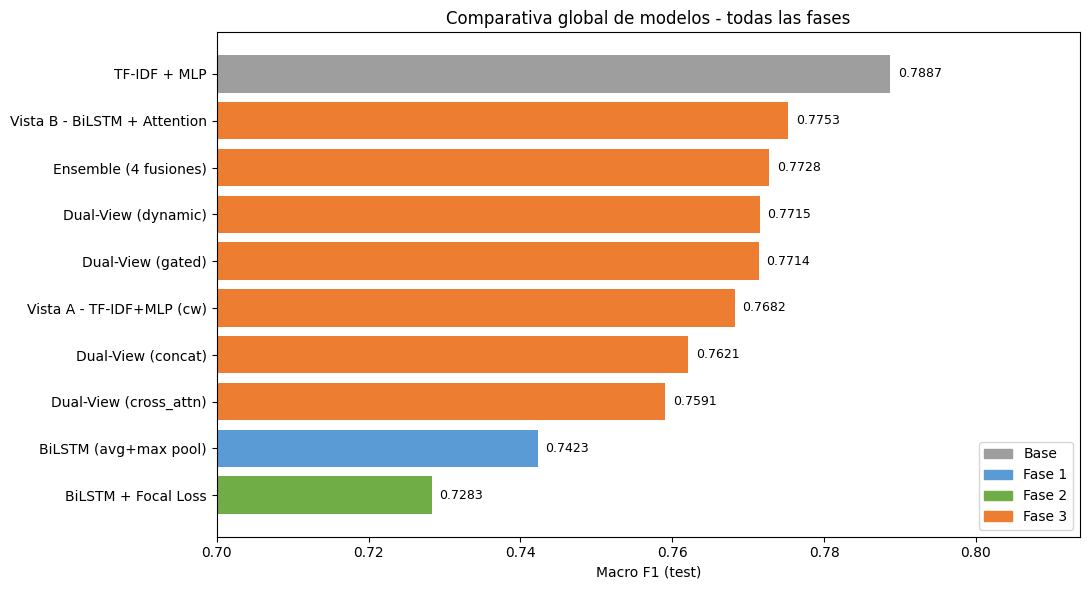

In [44]:
# === Gráfico comparativo de Macro F1 por modelo ===
_colors = {"Base": "#9E9E9E", "Fase 1": "#5B9BD5", "Fase 2": "#70AD47", "Fase 3": "#ED7D31"}
_bar_colors = [_colors.get(f, "#333333") for f in global_df["fase"]]

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(range(len(global_df)), global_df["macro_f1"], color=_bar_colors)
ax.set_yticks(range(len(global_df)))
ax.set_yticklabels(global_df["model"])
ax.invert_yaxis()
ax.set_xlabel("Macro F1 (test)")
ax.set_title("Comparativa global de modelos - todas las fases")
ax.set_xlim(0.70, float(global_df["macro_f1"].max()) + 0.025)
for i, v in enumerate(global_df["macro_f1"]):
    ax.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=f) for f, c in _colors.items()], loc="lower right")
plt.tight_layout()
plt.show()

### Cómo leer esta tabla

- **Si la Fase 3 encabeza** (Vista B o alguna fusión Dual-View) -> la progresión por fases funcionó: el enfoque secuencial con fusión intra-modal es el mejor para esta modalidad.
- **Si una fase intermedia gana** -> ese fue el salto clave y conviene destacarlo.
- Comparar la columna `f1_adware` entre fases muestra qué estrategia ayudó más a la clase minoritaria: *class weights* (Base/Fase 3) vs *Focal Loss* (Fase 2).

> **Nota metodológica:** las Fases 1, 2 y 3 usan preprocesamientos de secuencia ligeramente distintos (tamaño de vocabulario y `max_len`), por lo que esta comparación es indicativa de la *aproximación*, no un control experimental perfecto. El control estricto (mismo split y preprocesamiento) está **dentro** de la Fase 3, donde los 7 modelos se comparan en igualdad de condiciones.